<a href="https://colab.research.google.com/github/asnavirmedia01/heart-disease-prediction-model/blob/main/Heart_Disease_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HEAD AND DESCRIPTION OF DATASET

In [ ]:
import pandas as pd

# Replace with your actual path
file_path = '/content/drive/MyDrive/heart_disease_dataset.csv'

# Load the dataset
df = pd.read_csv(file_path)

In [ ]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,Stress Level,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,69,Male,110,269,Moderate,Yes,Yes,No,23.9,Low,8.9,293,116,6.23,15.75,Yes
1,76,Male,91,223,Moderate,No,No,No,28.4,High,7.8,134,72,8.36,11.83,No
2,48,Female,117,187,High,No,Yes,Yes,33.9,Low,8.2,124,111,1.62,12.52,No
3,50,Female,137,304,Moderate,No,No,Yes,28.1,Low,6.6,82,136,8.66,18.38,No
4,61,Female,91,276,High,No,No,Yes,18.9,Medium,6.6,296,147,9.46,15.51,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   1500 non-null   int64  
 1   Gender                1500 non-null   object 
 2   Blood Pressure        1500 non-null   int64  
 3   Cholesterol Level     1500 non-null   int64  
 4   Exercise Habits       1500 non-null   object 
 5   Smoking               1500 non-null   object 
 6   Family Heart Disease  1500 non-null   object 
 7   Diabetes              1500 non-null   object 
 8   BMI                   1500 non-null   float64
 9   Stress Level          1500 non-null   object 
 10  Sleep Hours           1500 non-null   float64
 11  Triglyceride Level    1500 non-null   int64  
 12  Fasting Blood Sugar   1500 non-null   int64  
 13  CRP Level             1500 non-null   float64
 14  Homocysteine Level    1500 non-null   float64
 15  Heart Disease Status 

In [ ]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,54.273333,134.408000,235.158667,26.465000,6.504667,214.995333,123.477333,5.117067,12.428220
std,14.460637,25.911435,48.244404,4.914037,1.441926,78.070113,31.328408,2.871964,4.342527
min,30.000000,90.000000,150.000000,18.000000,4.000000,80.000000,70.000000,0.100000,5.000000
25%,42.000000,112.000000,193.000000,22.200000,5.300000,148.750000,96.750000,2.657500,8.697500
50%,54.000000,134.000000,236.000000,26.400000,6.500000,217.000000,123.000000,5.205000,12.255000
75%,67.000000,157.000000,275.250000,30.700000,7.800000,282.000000,151.000000,7.620000,16.160000
max,79.000000,179.000000,319.000000,35.000000,9.000000,349.000000,179.000000,10.000000,19.990000


# IMPORTING OF LIBRARIES TO BE USED

In [ ]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set(style="whitegrid")

# COLUMNS AND THEIR TYPES

In [ ]:
# Identify column types
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", list(num_cols))
print("Categorical Columns:", list(cat_cols))

Numerical Columns: ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']
Categorical Columns: ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'Stress Level', 'Heart Disease Status']


In [ ]:
print("Shape of Original Dataset:", df.shape)

Shape of Original Dataset: (1500, 16)



Target Value Counts:
Heart Disease Status
No     771
Yes    729
Name: count, dtype: int64


/tmp/ipython-input-3632424596.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette="coolwarm")


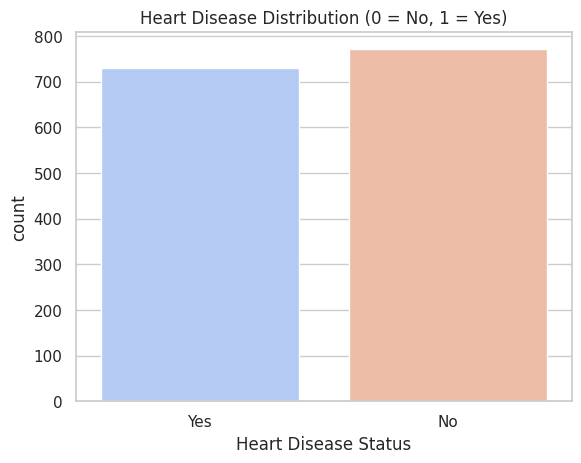

In [ ]:
target_col = "Heart Disease Status"   # replace with actual target name if different
print("\nTarget Value Counts:")
print(df[target_col].value_counts())

sns.countplot(x=target_col, data=df, palette="coolwarm")
plt.title("Heart Disease Distribution (0 = No, 1 = Yes)")
plt.show()

In [ ]:
print("Distribution of Gender:\n")
print(df['Gender'].value_counts())

Distribution of Gender:

Gender
Female    780
Male      720
Name: count, dtype: int64


In [ ]:
print(df.describe())
print(df.columns)

               Age  Blood Pressure  Cholesterol Level          BMI  \
count  1500.000000     1500.000000        1500.000000  1500.000000   
mean     54.273333      134.408000         235.158667    26.465000   
std      14.460637       25.911435          48.244404     4.914037   
min      30.000000       90.000000         150.000000    18.000000   
25%      42.000000      112.000000         193.000000    22.200000   
50%      54.000000      134.000000         236.000000    26.400000   
75%      67.000000      157.000000         275.250000    30.700000   
max      79.000000      179.000000         319.000000    35.000000   

       Sleep Hours  Triglyceride Level  Fasting Blood Sugar    CRP Level  \
count  1500.000000         1500.000000          1500.000000  1500.000000   
mean      6.504667          214.995333           123.477333     5.117067   
std       1.441926           78.070113            31.328408     2.871964   
min       4.000000           80.000000            70.000000     0

# MISSING VALUES & DATA CLEANING

In [ ]:
print("🔍 Missing Values in Raw Dataset:\n")
missing = df.isna().sum()
missing = missing[missing > 0]  # Only show columns that actually have missing values

if not missing.empty:
    print(missing)
else:
    print("No missing values found.")

🔍 Missing Values in Raw Dataset:

No missing values found.


In [ ]:
# Confirm if dataset is completely clean
if df.isnull().sum().sum() == 0:
    print("✅ No missing values found in the dataset!")
else:
    print("⚠️ There are still missing values present.")

✅ No missing values found in the dataset!


# DUPLICATE ROWS AND POTENTIAL OUTLIERS

In [ ]:
# Identify and count duplicate rows
initial_rows = df.shape[0]
duplicate_rows = df.duplicated().sum()

print(f"Initial number of rows: {initial_rows}")
print(f"Number of duplicate rows found: {duplicate_rows}")

# Remove duplicate rows
df.drop_duplicates(inplace=True)
rows_after_dropping = df.shape[0]

print(f"Number of rows after dropping duplicates: {rows_after_dropping}")

Initial number of rows: 1500
Number of duplicate rows found: 0
Number of rows after dropping duplicates: 1500


In [ ]:
# Identify all numeric columns in the dataset
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("🔢 Numerical Columns:")
print(numerical_cols)

🔢 Numerical Columns:
Index(['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours',
       'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level',
       'Homocysteine Level'],
      dtype='object')


# OUTLIERS

In [ ]:
outliers_data = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_data[col] = len(outliers)

print("Number of outliers per numerical column (using IQR method):")
for col, count in outliers_data.items():
    print(f"{col}: {count}")


Number of outliers per numerical column (using IQR method):
Age: 0
Blood Pressure: 0
Cholesterol Level: 0
BMI: 0
Sleep Hours: 0
Triglyceride Level: 0
Fasting Blood Sugar: 0
CRP Level: 0
Homocysteine Level: 0


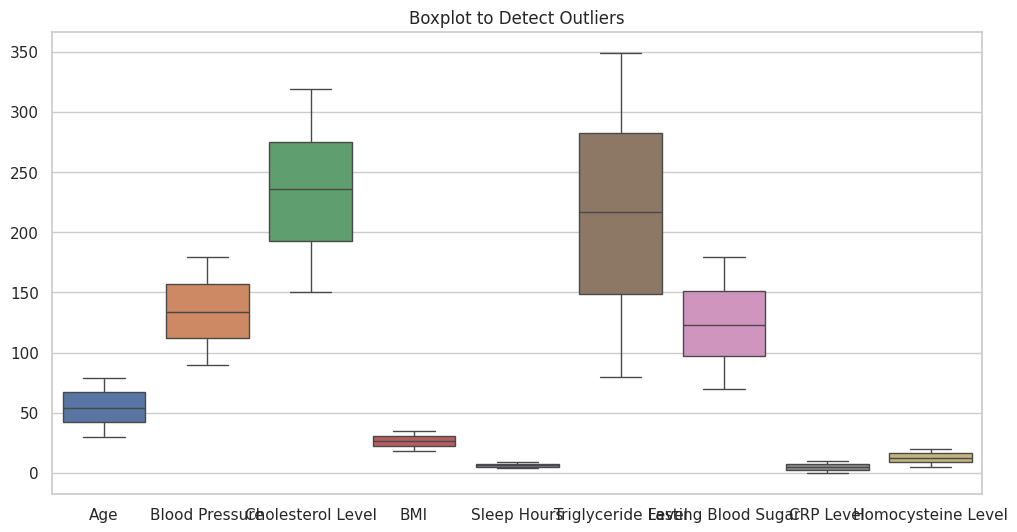

In [ ]:
# Visualize potential outliers in all numeric columns using a boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data= df[numerical_cols])
plt.title("Boxplot to Detect Outliers")
plt.show()

**OUTLIERS**

Outliers are data points that deviate significantly from the rest of the dataset. They can occur due to measurement errors, data entry mistakes, or genuine variability in the data. Outliers can distort statistical analyses and affect the performance of machine learning models by pulling averages or trends away from the true pattern.

To handle outliers, techniques such as the **Interquartile Range (IQR) method**, **z-score method**, or **data transformation** are commonly used. Depending on the context, outliers can be **removed**, **capped**, or **retained** if they represent meaningful variations in the data.


In [ ]:
# Define a function to detect outliers
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Example for 'Homocysteine Level'
detect_outliers('Homocysteine Level')

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,Stress Level,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status


# BOXPLOT FOR NUMERIAL COLUMNS

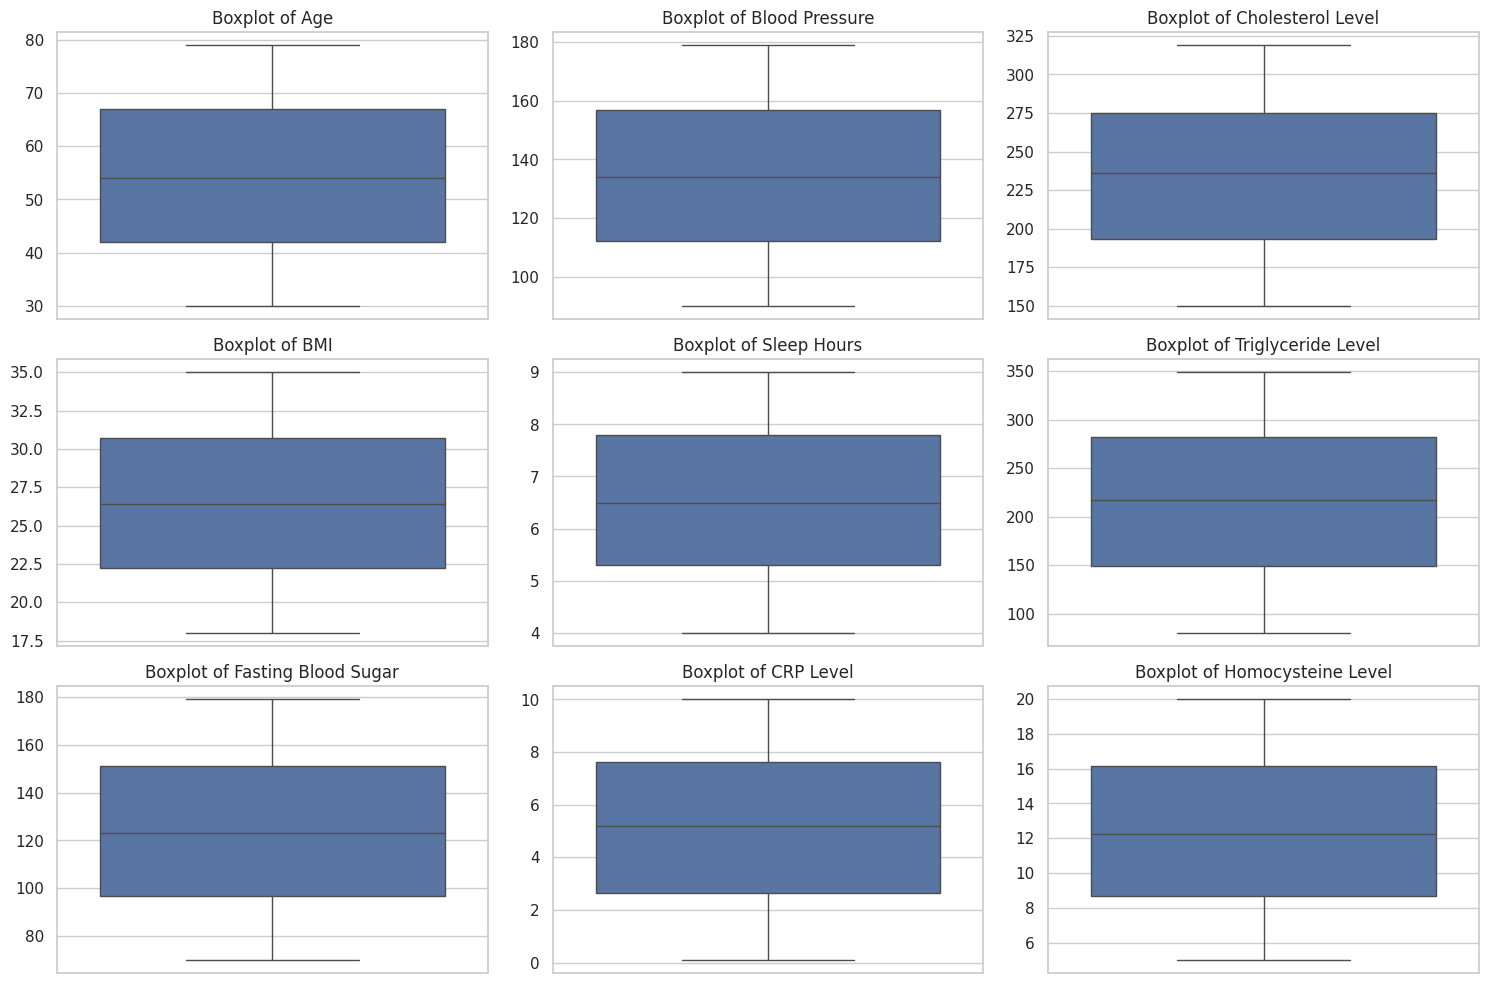

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()

**BOXPLOTS EXPLANATION**

Boxplots are a standardized way to display the distribution of data based on a five-number summary: minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum. They are particularly useful for visualizing the spread and skewness of data, and for identifying outliers.

Here's what each part of a boxplot represents:

-   **Minimum**: The lowest data point, excluding outliers.
-   **First Quartile (Q1)**: The 25th percentile, meaning 25% of the data falls below this value. It marks the bottom of the box.
-   **Median (Q2)**: The 50th percentile, which is the middle value of the dataset. It's the line inside the box.
-   **Third Quartile (Q3)**: The 75th percentile, meaning 75% of the data falls below this value. It marks the top of the box.
-   **Maximum**: The highest data point, excluding outliers.
-   **Interquartile Range (IQR)**: The range between Q1 and Q3 (IQR = Q3 - Q1). The box itself represents the IQR, containing the middle 50% of the data.
-   **Whiskers**: These lines extend from the top and bottom of the box to the lowest and highest data points within 1.5 times the IQR from the Q1 and Q3 respectively. Data points outside these whiskers are considered potential outliers.
-   **Outliers**: Individual points plotted beyond the whiskers. These are values that are significantly different from the rest of the data and may warrant further investigation.

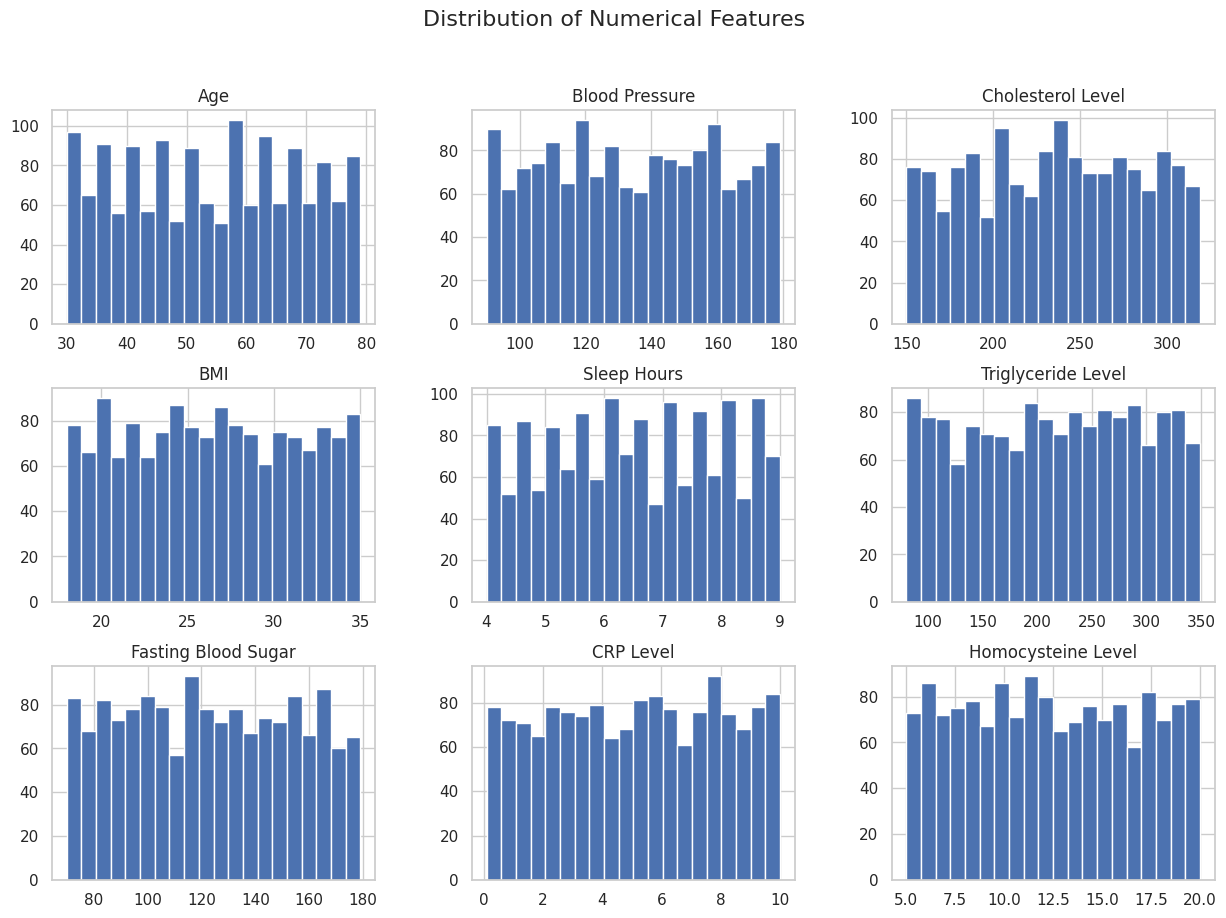

In [ ]:
# Histograms for numerical columns
df[num_cols].hist(figsize=(15, 10), bins=20)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

# COUNT PLOTS FOR CATEGORICAL COLUMNS

/tmp/ipython-input-409559093.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipython-input-409559093.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipython-input-409559093.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipython-input-409559093.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same

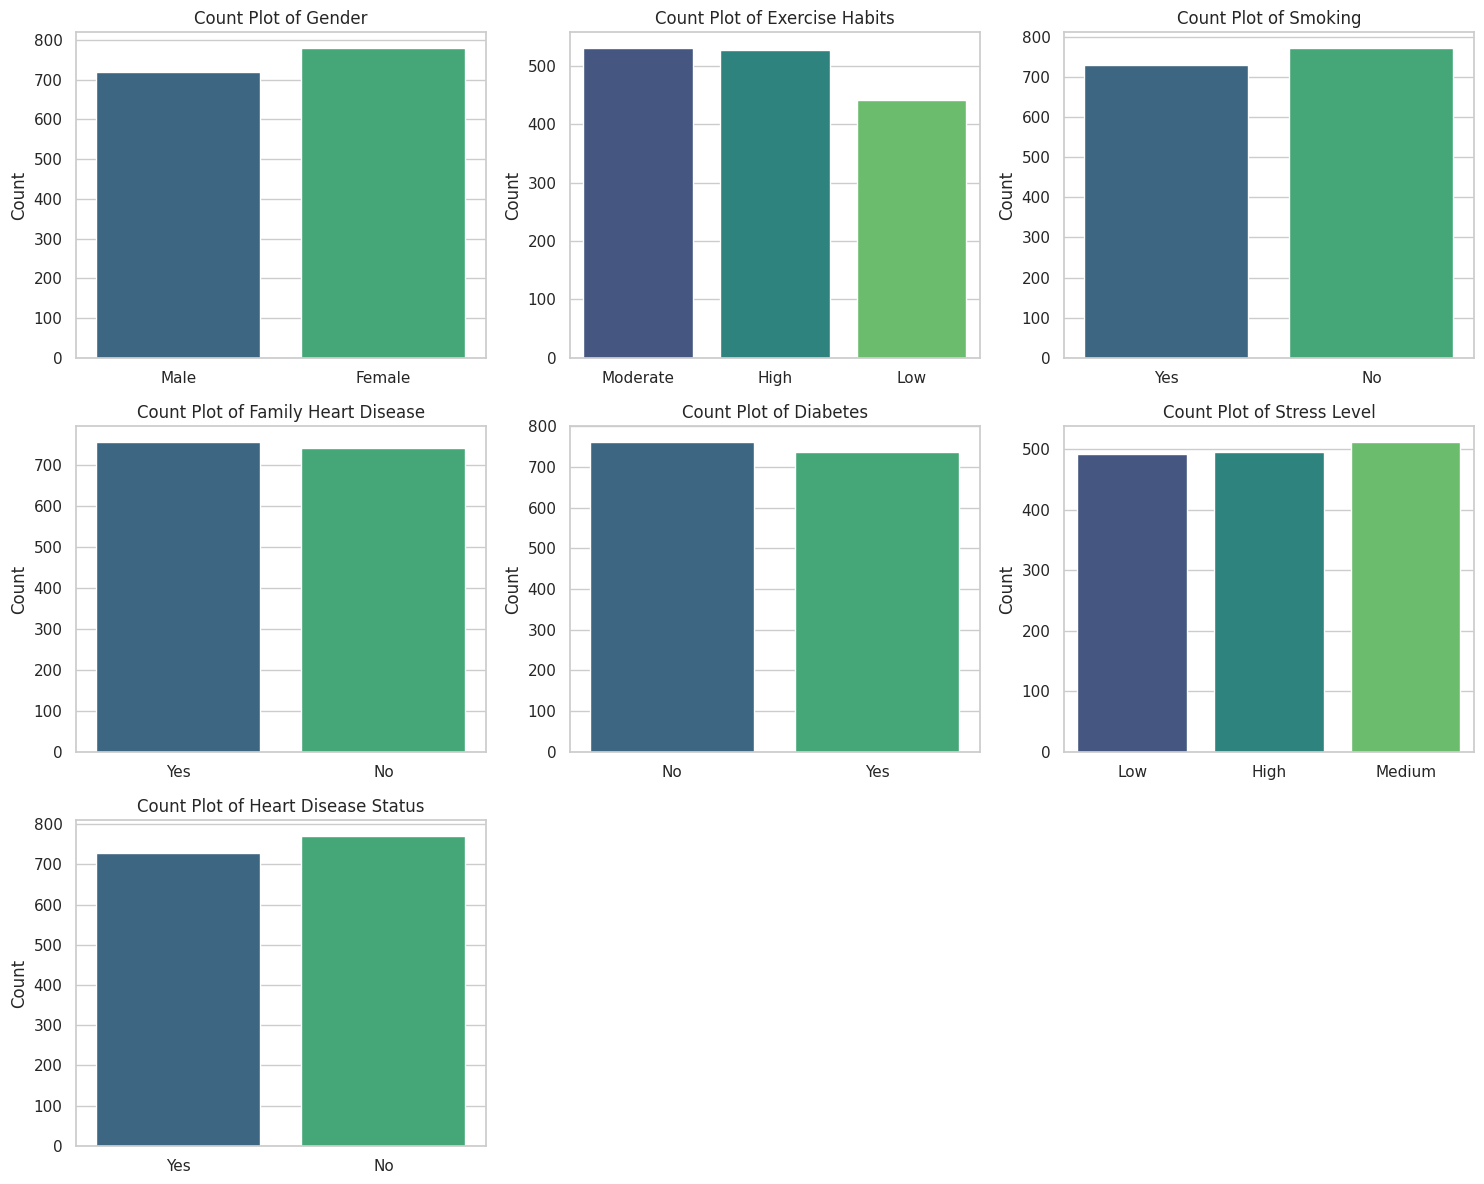

In [ ]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(cat_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f'Count Plot of {col}')
    plt.xlabel('')
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1762220346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Heart Disease Status', data=df, palette=['green', 'blue'])


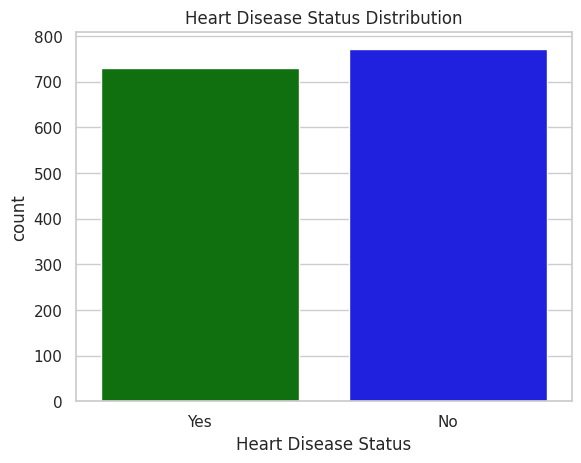

Heart Disease Status,No,Yes
Gender,,
Female,51.538462,48.461538
Male,51.250000,48.750000


In [ ]:
# Heart Disease Status distribution
sns.countplot(x='Heart Disease Status', data=df, palette=['green', 'blue'])
plt.title('Heart Disease Status Distribution')
plt.show()

# Cross-tab with Gender or Smoking
pd.crosstab(df['Gender'], df['Heart Disease Status'], normalize='index') * 100

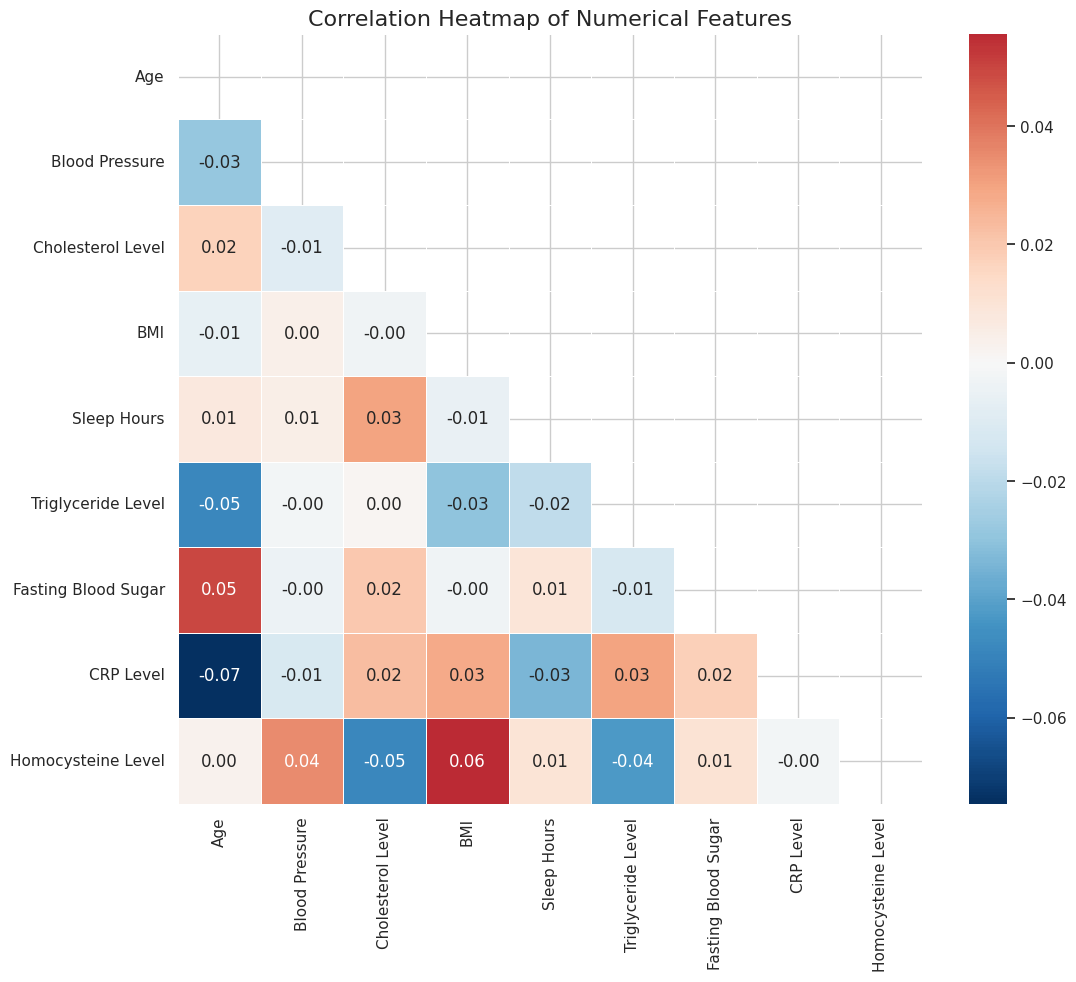

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical columns
correlation_matrix = df[num_cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Create a mask for the upper triangle to avoid redundant information
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Draw the heatmap with the mask and a 2-color divergent palette (e.g., 'RdBu_r' or 'coolwarm')
# 'RdBu_r' will show red for positive and blue for negative; 'coolwarm' will show red for positive and blue for negative
# 'center=0' ensures that 0 correlation is the neutral color in the palette.
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=.5, mask=mask, center=0)

plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

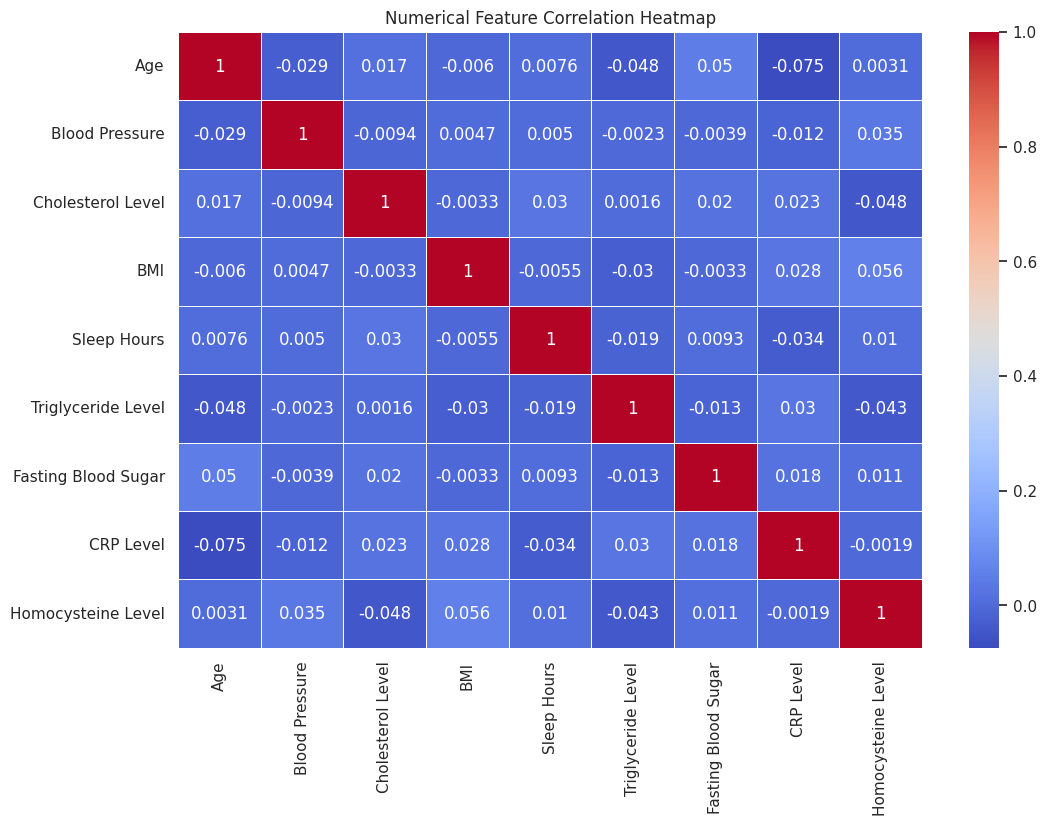

In [ ]:
num_df = df.select_dtypes(include=['int64','float64'])

corr = num_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", linewidths=0.5, annot=True)
plt.title("Numerical Feature Correlation Heatmap")
plt.show()


**DETAILED CORRELATION HEATMAP EXPLANATION**

A **correlation heatmap** is a powerful data visualization tool that graphically displays a correlation matrix, which quantifies the linear relationship between pairs of numerical variables in a dataset. It uses a color-coded grid to represent correlation coefficients, making it easy to identify patterns and relationships at a glance.

**Components and Interpretation:**

1.  **What is a Correlation Coefficient?**
    *   The values displayed in each cell of the heatmap are Pearson correlation coefficients (often denoted as 'r'). These coefficients measure the strength and direction of a linear relationship between two variables. They range from -1 to +1.

2.  **Color and Intensity:**
    *   **Direction of Relationship:** In a two-color diverging palette (like 'RdBu_r' or 'coolwarm'), one color (e.g., red) typically represents **negative correlations**, while the other color (e.g., blue) represents **positive correlations**.
        *   **Positive Correlation:** If two variables have a positive correlation (e.g., as 'Age' increases, 'Cholesterol Level' also tends to increase), the cell will be colored in shades of blue. The more intense the blue, the stronger the positive relationship.
        *   **Negative Correlation:** If two variables have a negative correlation (e.g., as 'Exercise Hours' increase, 'BMI' tends to decrease), the cell will be colored in shades of red. The more intense the red, the stronger the negative relationship.
        *   **No Correlation:** A light or neutral color (often white or a muted grey/purple near the center of the palette) indicates little to no linear relationship between the variables (a correlation coefficient close to 0).
    *   **Strength of Relationship:** The intensity or saturation of the color directly corresponds to the magnitude (absolute value) of the correlation coefficient. More vibrant and darker shades signify stronger correlations (closer to -1 or +1), while lighter shades indicate weaker correlations (closer to 0).

3.  **Specific Coefficient Values:**
    *   **+1:** A perfect positive linear relationship. This means that as one variable increases, the other increases proportionally in exactly the same way.
    *   **-1:** A perfect negative linear relationship. This means that as one variable increases, the other decreases proportionally in exactly the same way.
    *   **0:** No linear correlation. This implies that there is no straightforward linear pattern between the two variables. It's important to note that a zero correlation doesn't mean there's *no relationship* at all, just no *linear* relationship (e.g., a perfect parabolic relationship would have a correlation of 0).
    *   **Values between 0 and 1 (or -1 and 0):** Indicate varying degrees of positive or negative linear relationships. For example, 0.7 suggests a strong positive relationship, while -0.3 suggests a weak negative relationship.

4.  **The Diagonal:**
    *   The cells along the main diagonal (from top-left to bottom-right) always show a correlation of 1.00. This is because each variable is perfectly correlated with itself.

5.  **Symmetry:**
    *   A correlation matrix is always symmetrical. The correlation between Variable A and Variable B is the same as the correlation between Variable B and Variable A. Therefore, the heatmap is a mirror image across its diagonal. To avoid redundancy, heatmaps often mask out the upper or lower triangle.

**Why is it useful?**

*   **Quick Overview:** Provides a quick visual summary of all pairwise correlations.
*   **Feature Selection:** Helps in identifying highly correlated features, which might be redundant or problematic for some machine learning models (e.g., multicollinearity).
*   **Understanding Relationships:** Reveals which variables tend to move together (positively correlated) and which tend to move in opposite directions (negatively correlated).

#RELATIONSHIP BETWEEN VARIABLES

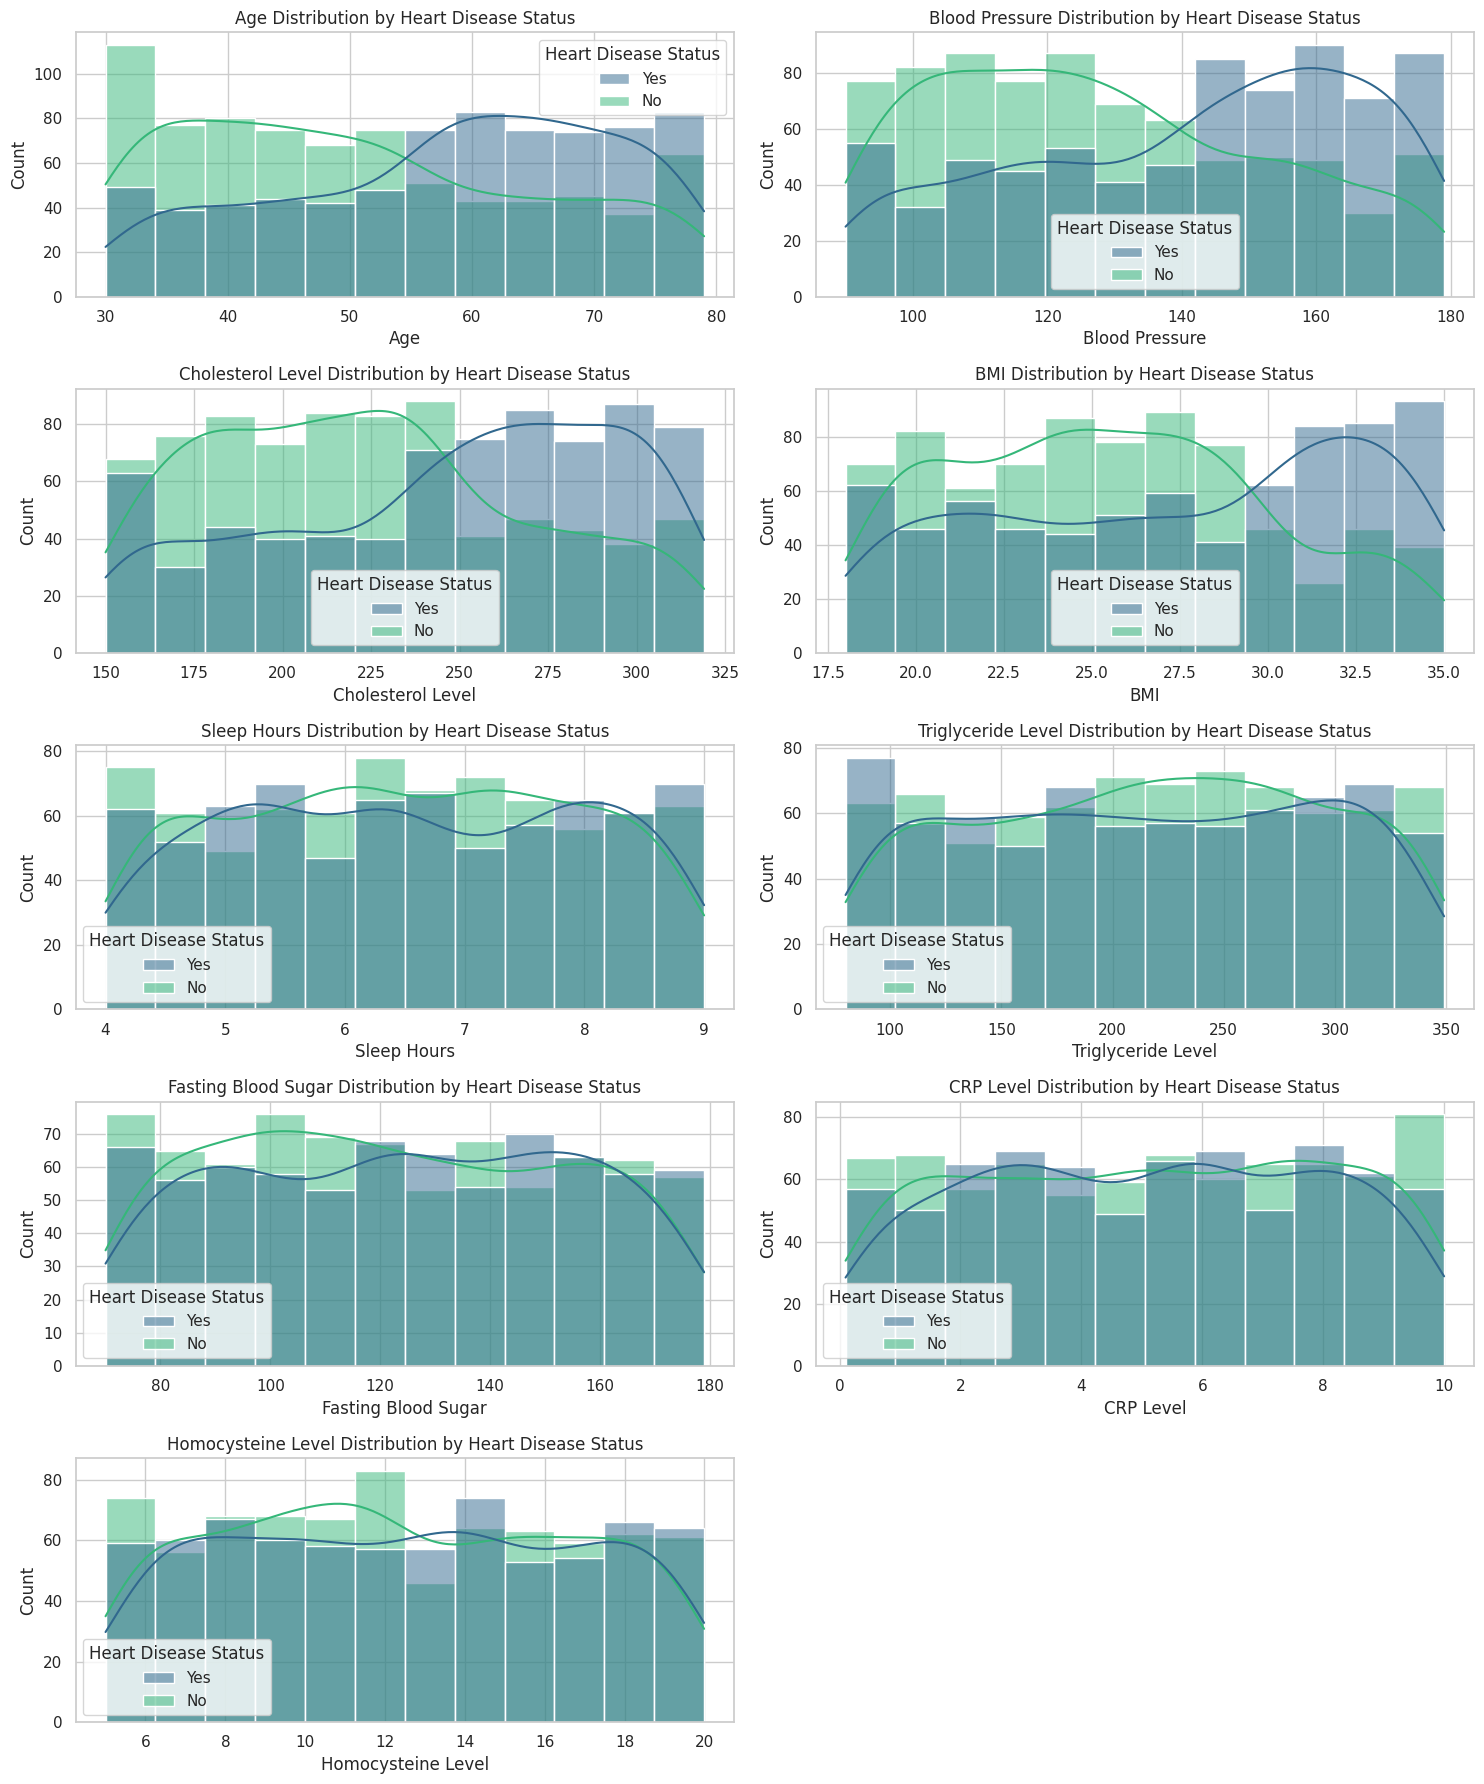

In [ ]:
num_cols_for_relation = [col for col in numerical_cols if col != target_col] # Exclude target_col if it's numerical

plt.figure(figsize=(15, 18)) # Adjust figure size as needed
for i, col in enumerate(num_cols_for_relation):
    plt.subplot(len(num_cols_for_relation) // 2 + 1, 2, i + 1) # Arrange plots in a grid
    sns.histplot(data=df, x=col, hue=target_col, kde=True, palette='viridis', alpha=0.5)
    plt.title(f'{col} Distribution by Heart Disease Status')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

#COMPREHENSIVE VISUALIZATION

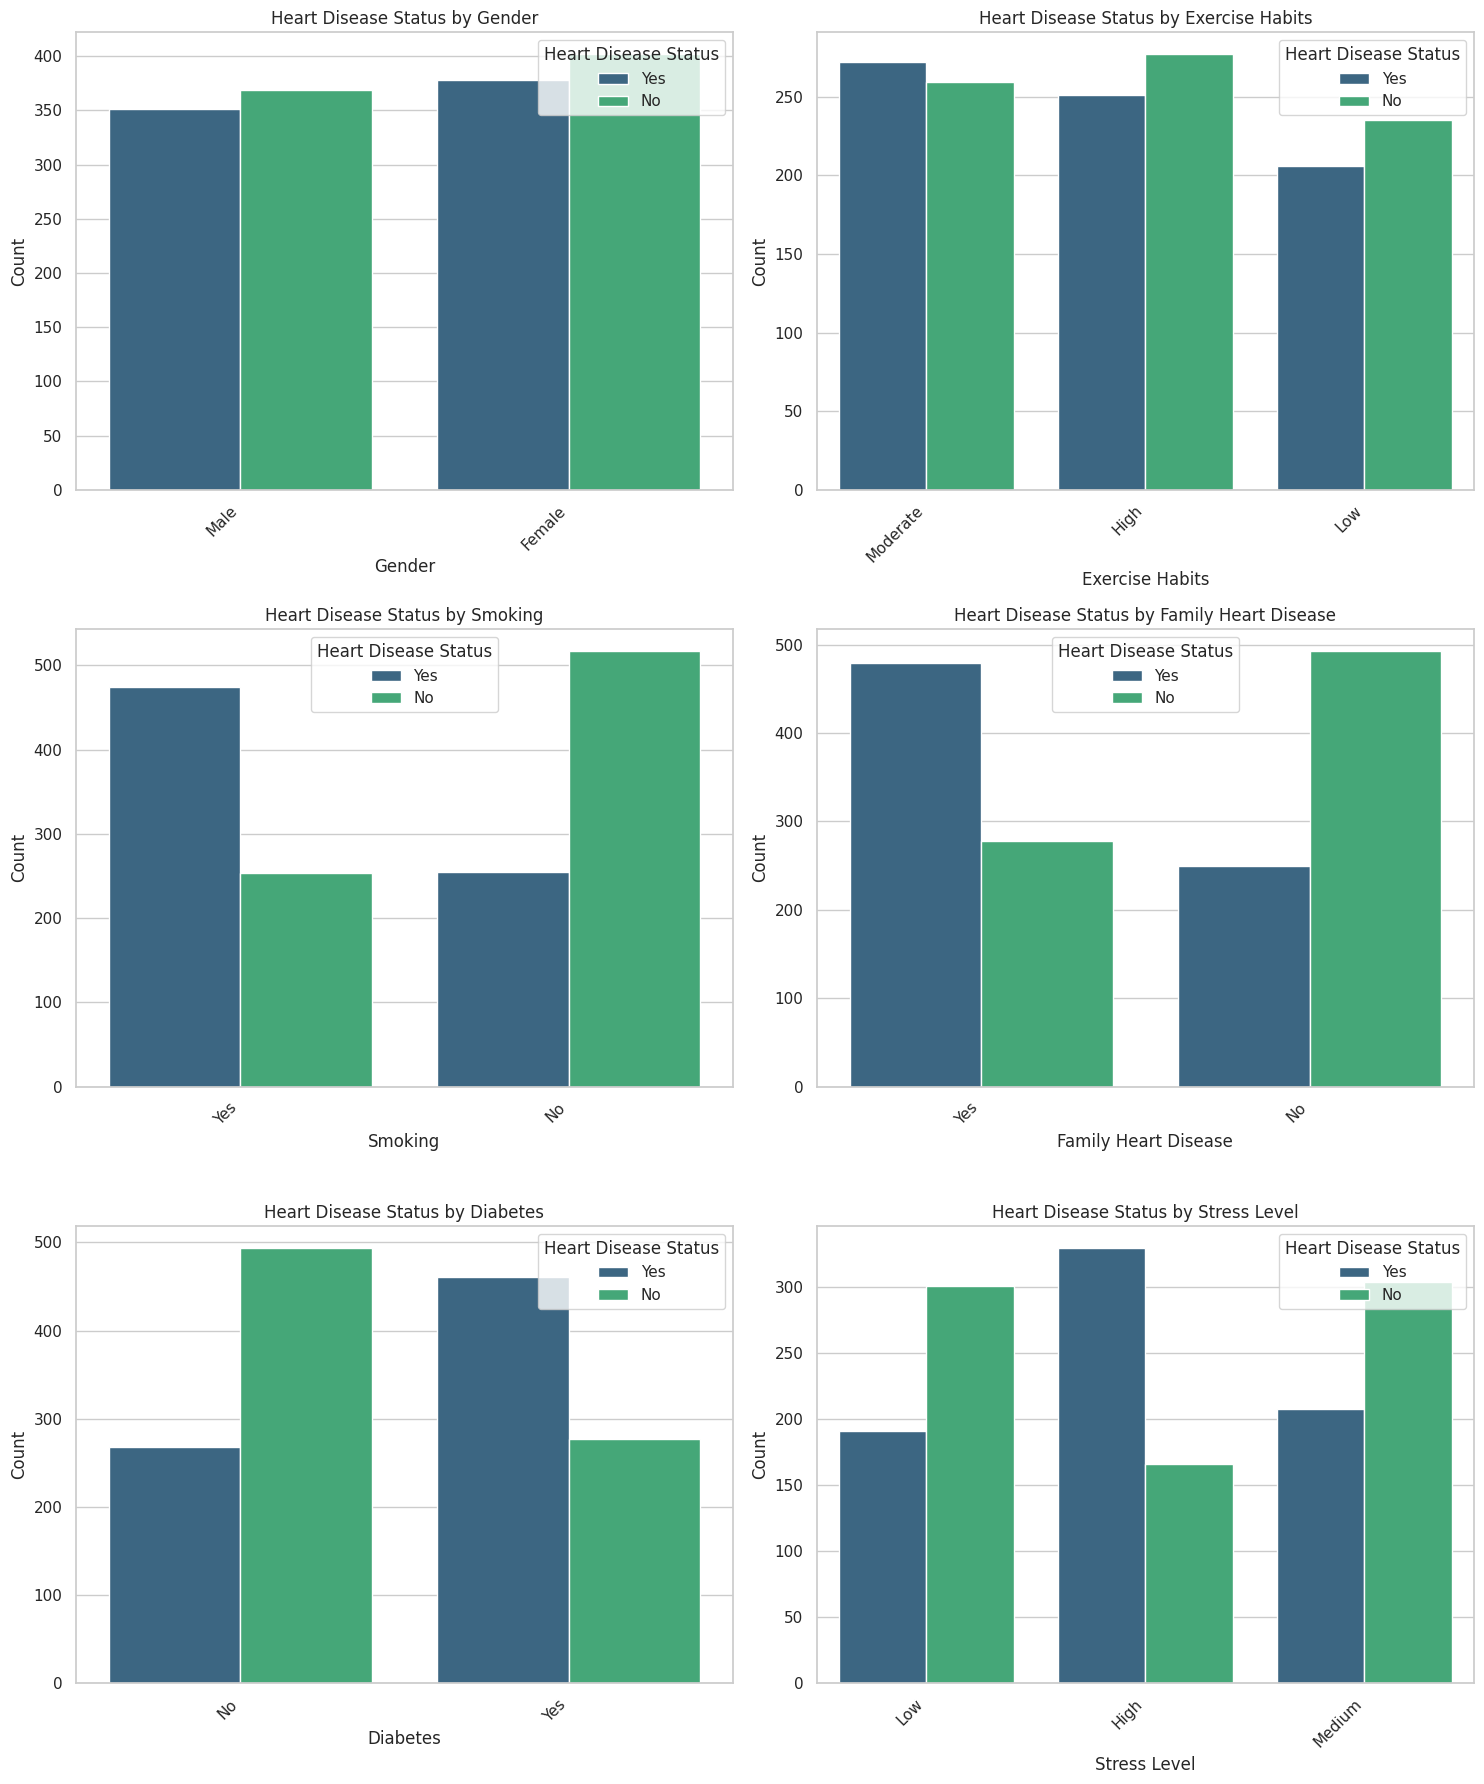

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out 'Heart Disease Status' from the list of categorical columns
independent_cat_cols = [col for col in cat_cols if col != 'Heart Disease Status']

# Set up figure size and subplot grid dynamically
num_plots = len(independent_cat_cols)
num_cols_subplot = 2  # Number of columns in the subplot grid
num_rows_subplot = (num_plots + num_cols_subplot - 1) // num_cols_subplot # Calculate number of rows needed

plt.figure(figsize=(15, 6 * num_rows_subplot)) # Adjust figure size dynamically

for i, col in enumerate(independent_cat_cols):
    plt.subplot(num_rows_subplot, num_cols_subplot, i + 1)
    sns.countplot(x=df[col], hue='Heart Disease Status', data=df, palette='viridis')
    plt.title(f'Heart Disease Status by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

plt.tight_layout()
plt.show()

# ENCODING OF DATASET

In [ ]:
from sklearn.preprocessing import LabelEncoder

print("Encoding for all categorical columns:")

# Identify categorical columns to be encoded
label_cols = df.select_dtypes(include='object').columns

for col in label_cols:
    # Create a new LabelEncoder for each column to ensure independent mapping
    encoder_specific = LabelEncoder()
    # Fit on the original (non-encoded) column to get the class names
    encoder_specific.fit(df[col])

    print(f"\nColumn: '{col}'")
    # Display the mapping for each unique class in the column
    for i, label in enumerate(encoder_specific.classes_):
        print(f"  '{label}' is encoded as {i}")

Encoding for all categorical columns:

Column: 'Gender'
  'Female' is encoded as 0
  'Male' is encoded as 1

Column: 'Exercise Habits'
  'High' is encoded as 0
  'Low' is encoded as 1
  'Moderate' is encoded as 2

Column: 'Smoking'
  'No' is encoded as 0
  'Yes' is encoded as 1

Column: 'Family Heart Disease'
  'No' is encoded as 0
  'Yes' is encoded as 1

Column: 'Diabetes'
  'No' is encoded as 0
  'Yes' is encoded as 1

Column: 'Stress Level'
  'High' is encoded as 0
  'Low' is encoded as 1
  'Medium' is encoded as 2

Column: 'Heart Disease Status'
  'No' is encoded as 0
  'Yes' is encoded as 1


In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib

df_encoded = df.copy()

label_cols = df.select_dtypes(include='object').columns

# Dictionary to store fitted LabelEncoders
label_encoders = {}

for col in label_cols:
    encoder = LabelEncoder()
    df_encoded[col] = encoder.fit_transform(df_encoded[col])
    label_encoders[col] = encoder # Save the fitted encoder

# Save the dictionary of encoders
joblib.dump(label_encoders, 'label_encoders.joblib')
print("Fitted LabelEncoders saved to 'label_encoders.joblib'")

Fitted LabelEncoders saved to 'label_encoders.joblib'


In [ ]:
df_encoded.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,Stress Level,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,69,1,110,269,2,1,1,0,23.9,1,8.9,293,116,6.23,15.75,1
1,76,1,91,223,2,0,0,0,28.4,0,7.8,134,72,8.36,11.83,0
2,48,0,117,187,0,0,1,1,33.9,1,8.2,124,111,1.62,12.52,0
3,50,0,137,304,2,0,0,1,28.1,1,6.6,82,136,8.66,18.38,0
4,61,0,91,276,0,0,0,1,18.9,2,6.6,296,147,9.46,15.51,0


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

# Separate features and target
X = df_encoded.drop("Heart Disease Status", axis=1)
y = df_encoded["Heart Disease Status"]

# Train-test split (using X and y defined above)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data (X_train) and transform both X_train and X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames, preserving column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Save the fitted scaler
joblib.dump(scaler, 'scaler.joblib')
print("Fitted StandardScaler saved to 'scaler.joblib'")

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Fitted StandardScaler saved to 'scaler.joblib'
Shape of X_train_scaled: (1200, 15)
Shape of X_test_scaled: (300, 15)


# TRAINING OF MODELS (with scaled data)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# X_train_scaled, X_test_scaled, y_train, y_test are assumed to be defined from previous steps (e.g., cell b75ea786)

model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight={0:1, 1:1.5},  # start caring more about sick patients
    random_state=42
)

model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight={0: 1, 1: 1.5}, max_depth=10,
                       min_samples_leaf=3, min_samples_split=5,
                       random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# X_train_scaled, X_test_scaled, y_train, y_test are assumed to be defined from previous steps (e.g., cell b75ea786)

model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight={0:1, 1:1.5},
    random_state=42
)

model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight={0: 1, 1: 1.5}, max_depth=10,
                       min_samples_leaf=3, min_samples_split=5,
                       random_state=42)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84       154
           1       0.83      0.84      0.84       146

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300



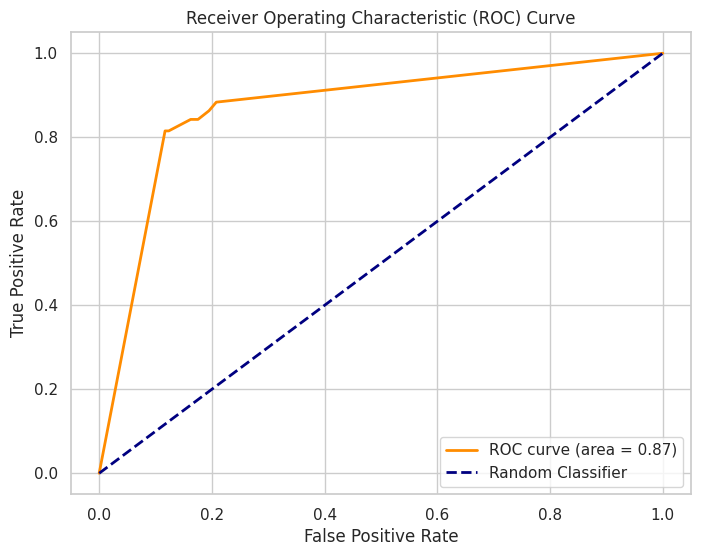

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for the test set
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define the hyperparameter grid
param_grid = {
    'max_depth': [2, 4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 3, 4, 5]
}

# Initialize the DecisionTreeClassifier with the desired class_weight
dt_grid_model = DecisionTreeClassifier(random_state=42, class_weight={0:1, 1:1.5})

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dt_grid_model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_scaled, y_train)

print("GridSearchCV completed.")

Fitting 5 folds for each of 75 candidates, totalling 375 fits
GridSearchCV completed.


In [ ]:
best_dt_model = grid_search.best_estimator_

y_pred = best_dt_model.predict(X_test_scaled)

print("Classification Report for Tuned Model:")
print(classification_report(y_test, y_pred))

Classification Report for Tuned Model:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       154
           1       0.82      0.85      0.83       146

    accuracy                           0.83       300
   macro avg       0.83      0.83      0.83       300
weighted avg       0.83      0.83      0.83       300



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, recall_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}

results = []

for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    results.append([name, acc, recall])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Recall_Class_1"])
results_df.sort_values(by="Recall_Class_1", ascending=False)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 583, number of negative: 617
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000344 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1395
[LightGBM] [Info] Number of data points in the train set: 1200, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.485833 -> initscore=-0.056682
[LightGBM] [Info] Start training from score -0.056682


,Model,Accuracy,Recall_Class_1
5,AdaBoost,1.000000,1.000000
4,Gradient Boosting,0.993333,0.993151
7,XGBoost,0.973333,0.965753
8,LightGBM,0.956667,0.938356
3,Random Forest,0.933333,0.924658
6,Naive Bayes,0.873333,0.897260
0,Logistic Regression,0.856667,0.863014
2,SVM,0.866667,0.863014
1,KNN,0.763333,0.719178


In [ ]:
from sklearn.metrics import classification_report

for name, clf in models.items():
    y_pred = clf.predict(X_test_scaled)
    print(f"\n--- Classification Report for {name} ---")
    print(classification_report(y_test, y_pred))


--- Classification Report for Logistic Regression ---
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       154
           1       0.85      0.86      0.85       146

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300


--- Classification Report for KNN ---
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       154
           1       0.78      0.72      0.75       146

    accuracy                           0.76       300
   macro avg       0.76      0.76      0.76       300
weighted avg       0.76      0.76      0.76       300


--- Classification Report for SVM ---
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       154
           1       0.86      0.86      0.86       146

    accuracy                           0.87      

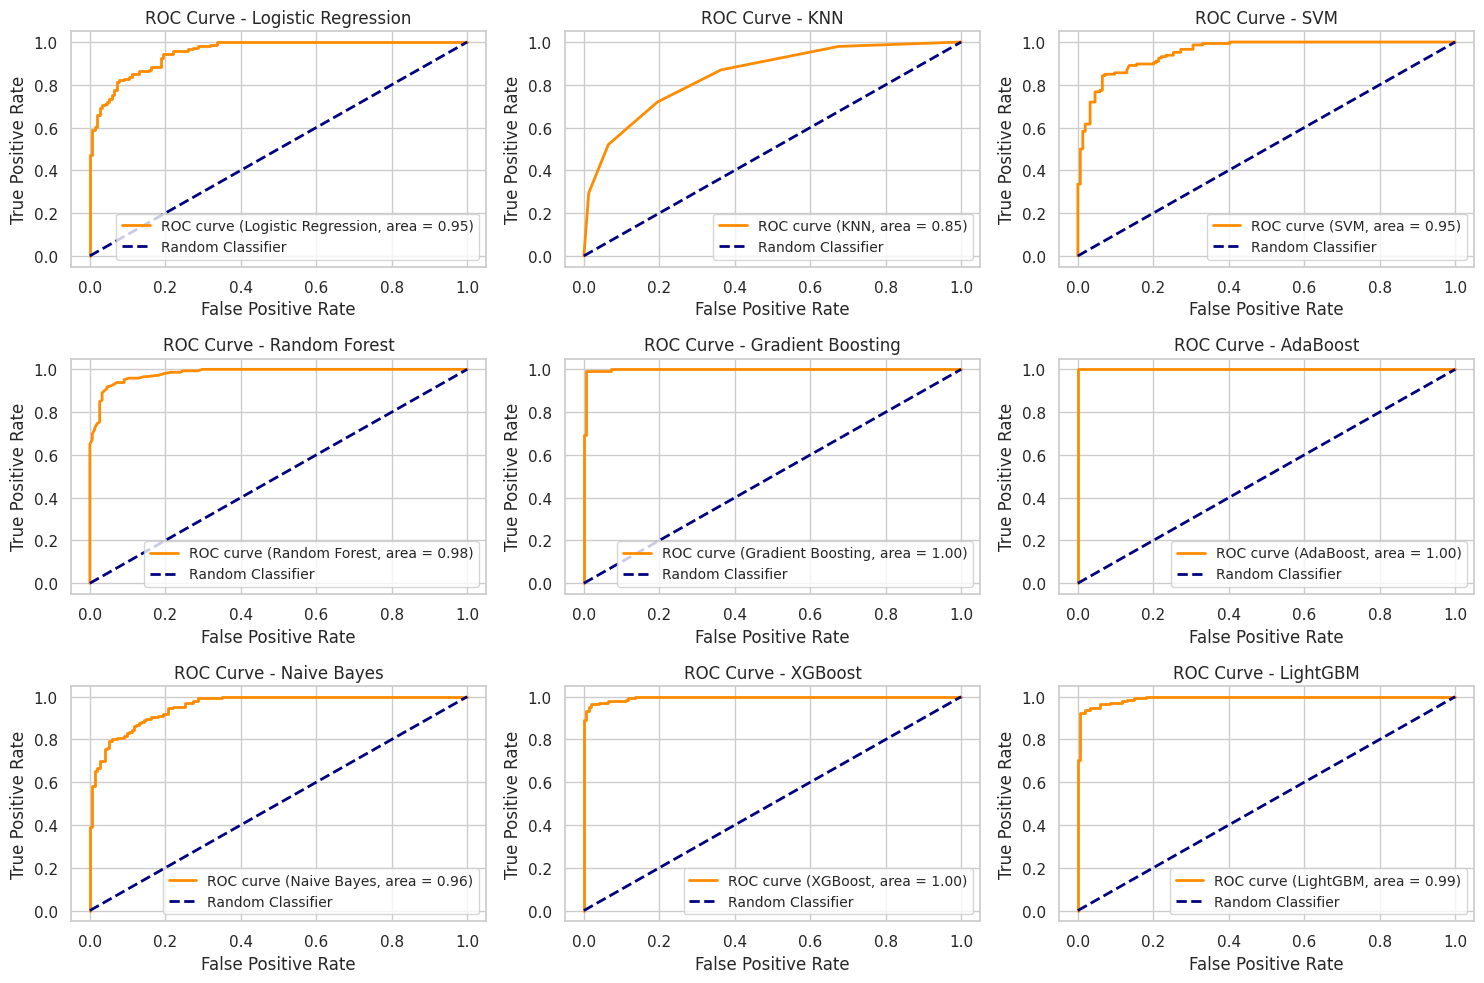

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

for i, (name, clf) in enumerate(models.items()):
    # Predict probabilities for the positive class
    y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]

    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed for 9 models
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve ({name}, area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(True)

plt.tight_layout()
plt.show()

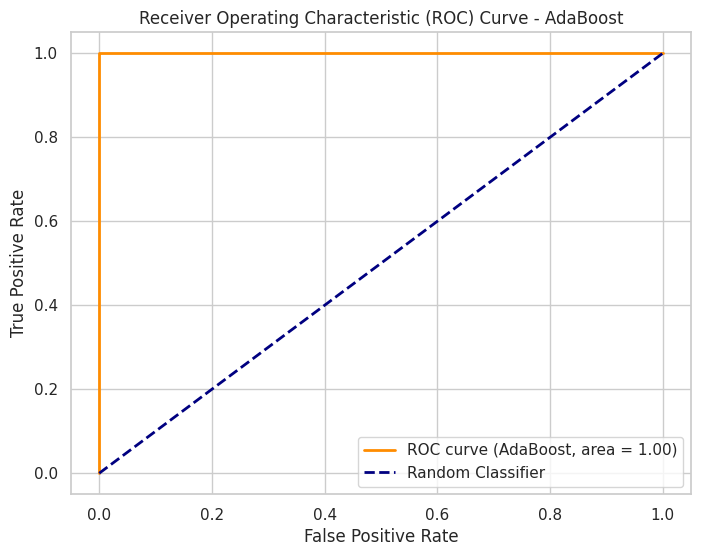

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get the AdaBoost model from the dictionary
adaboost_model = models['AdaBoost']

# Predict probabilities for the positive class
y_pred_proba_ada = adaboost_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve and AUC
fpr_ada, tpr_ada, thresholds_ada = roc_curve(y_test, y_pred_proba_ada)
roc_auc_ada = auc(fpr_ada, tpr_ada)

# Plot the ROC curve for AdaBoost
plt.figure(figsize=(8, 6))
plt.plot(fpr_ada, tpr_ada, color='darkorange', lw=2, label=f'ROC curve (AdaBoost, area = {roc_auc_ada:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - AdaBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
import joblib

try:
    # Load the best performing model
    loaded_model = joblib.load('best_ada_model.joblib')

    # Load the feature names
    loaded_feature_names = joblib.load('feature_names.joblib')

    # Load the label encoders
    loaded_label_encoders = joblib.load('label_encoders.joblib')

    # Load the scaler
    loaded_scaler = joblib.load('scaler.joblib')

    # Print the type of the loaded model
    print(f"Type of loaded_model: {type(loaded_model)}")

    # Print the loaded feature names
    print(f"Loaded feature names: {loaded_feature_names}")

    # Print the type of the loaded scaler
    print(f"Type of loaded_scaler: {type(loaded_scaler)}")
    print("All model artifacts loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading model artifacts: {e}")
    print("Please ensure you have run the cells that save the model, feature names, label encoders, and scaler first (cells IeiArl1MqLdI, 6185ca07, Tj9YgIPJeYXk, and b75ea786).")
    # Removed 'raise' to allow user to continue and save files.


Error loading model artifacts: [Errno 2] No such file or directory: 'best_ada_model.joblib'
Please ensure you have run the cells that save the model, feature names, label encoders, and scaler first (cells IeiArl1MqLdI, 6185ca07, Tj9YgIPJeYXk, and b75ea786).


In [ ]:
import pandas as pd
import joblib

try:
    # Load the best performing model and feature names
    loaded_model = joblib.load('best_ada_model.joblib')
    loaded_feature_names = joblib.load('feature_names.joblib')
    loaded_label_encoders = joblib.load('label_encoders.joblib') # Load the saved encoders
    loaded_scaler = joblib.load('scaler.joblib') # Load the saved scaler
except FileNotFoundError as e:
    print(f"Error loading model artifacts for predict_heart_disease function: {e}")
    print("Please ensure you have run the cells that save the model, feature names, label encoders, and scaler first (cells IeiArl1MqLdI, 6185ca07, Tj9YgIPJeYXk, and b75ea786).")
    # Removed 'raise' to allow user to continue and save files.

def predict_heart_disease(
    Smoking: str,
    Age: int,
    Family_Heart_Disease: str,
    BMI: float,
    Cholesterol_Level: int,
    Blood_Pressure: int,
    Stress_Level: str,
    Diabetes: str,
    Homocysteine_Level: float
) -> tuple:
    """
    Predicts heart disease status based on input features using a pre-trained model.

    Args:
        Smoking (str): 'Yes' or 'No'
        Age (int): Patient's age
        Family_Heart_Disease (str): 'Yes' or 'No'
        BMI (float): Body Mass Index
        Cholesterol_Level (int): Cholesterol level
        Blood_Pressure (int): Blood pressure
        Stress_Level (str): 'High', 'Low', or 'Medium'
        Diabetes (str): 'Yes' or 'No'
        Homocysteine_Level (float): Homocysteine level

    Returns:
        tuple: A tuple containing (pd.DataFrame of input features, str prediction result)
    """

    # Prepare a dictionary for the input values, matching the expected column names
    input_raw_data = {
        'Smoking': Smoking,
        'Age': Age,
        'Family Heart Disease': Family_Heart_Disease,
        'BMI': BMI,
        'Cholesterol Level': Cholesterol_Level,
        'Blood Pressure': Blood_Pressure,
        'Stress Level': Stress_Level,
        'Diabetes': Diabetes,
        'Homocysteine Level': Homocysteine_Level
    }

    # Create a DataFrame from the single row of input data
    input_df_processed = pd.DataFrame([input_raw_data])

    # Identify categorical and numerical columns based on `loaded_feature_names` and `loaded_label_encoders`
    cat_cols_to_encode = [col for col in loaded_label_encoders.keys() if col in input_df_processed.columns]

    num_cols_in_training_set = [col for col in loaded_feature_names if col not in loaded_label_encoders.keys()]
    num_cols_to_scale_in_input = [col for col in num_cols_in_training_set if col in input_df_processed.columns]

    # Encode categorical features using the loaded encoders
    for col in cat_cols_to_encode:
        encoder = loaded_label_encoders[col]
        input_df_processed[col] = encoder.transform(input_df_processed[col])

    # Select and order features according to the `loaded_feature_names`
    # Create a DataFrame with all original feature columns to ensure correct order and structure for scaling.
    # Fill missing columns with default/mean if any, though the function args should cover all needed.
    # Ensure `input_df_processed` has all features expected by `loaded_feature_names` (important_features).

    # Create an empty DataFrame with columns in the order of `loaded_feature_names`
    processed_features = pd.DataFrame(columns=loaded_feature_names)
    # Populate it with data from `input_df_processed`
    for col in loaded_feature_names:
        if col in input_df_processed.columns:
            processed_features[col] = input_df_processed[col]
        # Handle cases where a feature might be in loaded_feature_names but not in input_raw_data
        # (e.g., if a feature was important but not provided in function args, though current args cover important features)
        # For now, assuming direct mapping of input_df_processed to loaded_feature_names is sufficient for relevant features.

    # Apply scaler to numerical features
    # `input_df` is now `processed_features`
    processed_features[num_cols_to_scale_in_input] = loaded_scaler.transform(processed_features[num_cols_to_scale_in_input])

    # Use the loaded_model to make a prediction
    prediction = loaded_model.predict(processed_features)[0]

    # Convert the numerical prediction back into a user-friendly string
    if prediction == 1:
        result = 'Heart Disease Detected'
    else:
        result = 'No Heart Disease'

    # Return this user-friendly prediction string and the input DataFrame
    return processed_features, result

print("The `predict_heart_disease` function has been defined and loaded resources.")


Error loading model artifacts for predict_heart_disease function: [Errno 2] No such file or directory: 'best_ada_model.joblib'
Please ensure you have run the cells that save the model, feature names, label encoders, and scaler first (cells IeiArl1MqLdI, 6185ca07, Tj9YgIPJeYXk, and b75ea786).
The `predict_heart_disease` function has been defined and loaded resources.


##DEPLOYMENT FILES DOWNLOAD

In [ ]:
from google.colab import files

# Download the trained model file
try:
    files.download('best_ada_model.joblib')
except FileNotFoundError:
    print("Error: 'best_ada_model.joblib' not found. Please run cell IeiArl1MqLdI to save the model first.")

# Download the feature names file
try:
    files.download('feature_names.joblib')
except FileNotFoundError:
    print("Error: 'feature_names.joblib' not found. Please run cell 6185ca07 to save the feature names first.")

# Download the label encoders file
try:
    files.download('label_encoders.joblib')
except FileNotFoundError:
    print("Error: 'label_encoders.joblib' not found. Please run cell Tj9YgIPJeYXk to save the label encoders first.")

# Download the scaler file
try:
    files.download('scaler.joblib')
except FileNotFoundError:
    print("Error: 'scaler.joblib' not found. Please run cell b75ea786 to save the scaler first.")

print("Deployment files download attempt completed. Check for any specific FileNotFoundError messages above.")

Error: 'best_ada_model.joblib' not found. Please run cell IeiArl1MqLdI to save the model first.
Error: 'feature_names.joblib' not found. Please run cell 6185ca07 to save the feature names first.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Deployment files download attempt completed. Check for any specific FileNotFoundError messages above.


In [ ]:
# Save the encoded dataset to a new CSV file
df_encoded.to_csv('df_encoded.csv', index=False)
print("Encoded dataset saved as 'df_encoded.csv'")

Encoded dataset saved as 'df_encoded.csv'


# WORKING WITH ENCODED DATASET

This histogram visualizes the distribution of 'Heart Disease Status' across different genders. It shows the count of individuals diagnosed with 'Yes' or 'No' heart disease, separated by 'Male' and 'Female' categories. The 'multiple='dodge'' parameter ensures that the bars for 'Yes' and 'No' heart disease are displayed side-by-side for each gender, allowing for easy comparison of prevalence within each gender group.


/tmp/ipython-input-3829706017.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Heart Disease Status')


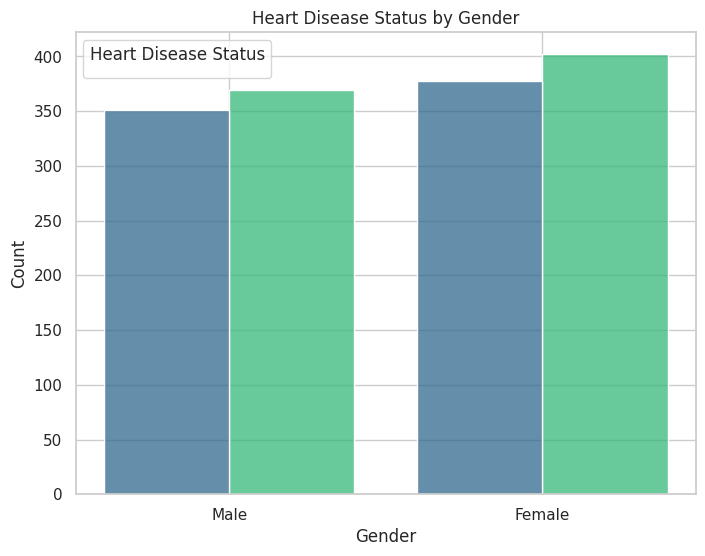

Heart Disease Status distribution by Gender (raw counts):
Heart Disease Status   No  Yes
Gender                        
Female                402  378
Male                  369  351


In [ ]:
print("This histogram visualizes the distribution of 'Heart Disease Status' across different genders. It shows the count of individuals diagnosed with 'Yes' or 'No' heart disease, separated by 'Male' and 'Female' categories. The 'multiple='dodge'' parameter ensures that the bars for 'Yes' and 'No' heart disease are displayed side-by-side for each gender, allowing for easy comparison of prevalence within each gender group.")
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Gender', hue='Heart Disease Status', multiple='dodge', shrink=0.8, palette='viridis')
plt.title('Heart Disease Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Heart Disease Status')
plt.show()
print("Heart Disease Status distribution by Gender (raw counts):")
print(pd.crosstab(df['Gender'], df['Heart Disease Status']))

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   1500 non-null   int64  
 1   Gender                1500 non-null   int64  
 2   Blood Pressure        1500 non-null   int64  
 3   Cholesterol Level     1500 non-null   int64  
 4   Exercise Habits       1500 non-null   int64  
 5   Smoking               1500 non-null   int64  
 6   Family Heart Disease  1500 non-null   int64  
 7   Diabetes              1500 non-null   int64  
 8   BMI                   1500 non-null   float64
 9   Stress Level          1500 non-null   int64  
 10  Sleep Hours           1500 non-null   float64
 11  Triglyceride Level    1500 non-null   int64  
 12  Fasting Blood Sugar   1500 non-null   int64  
 13  CRP Level             1500 non-null   float64
 14  Homocysteine Level    1500 non-null   float64
 15  Heart Disease Status 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Separate features and target
X = df_encoded.drop("Heart Disease Status", axis=1)
y = df_encoded["Heart Disease Status"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8133333333333334
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       154
           1       0.80      0.82      0.81       146

    accuracy                           0.81       300
   macro avg       0.81      0.81      0.81       300
weighted avg       0.81      0.81      0.81       300



#EXAMINE FEATURE IMPORTANCE


In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances)


Smoking                 0.150254
Age                     0.149243
Family Heart Disease    0.142843
BMI                     0.138994
Cholesterol Level       0.118014
Blood Pressure          0.111915
Stress Level            0.091055
Diabetes                0.064350
Homocysteine Level      0.015856
CRP Level               0.009311
Triglyceride Level      0.006391
Sleep Hours             0.001773
Gender                  0.000000
Exercise Habits         0.000000
Fasting Blood Sugar     0.000000
dtype: float64


In [ ]:
important_features = importances[importances > 0.01].index

X_reduced = X[important_features]


#TRAINING OF MODELS

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight={0:1, 1:1.5},  # start caring more about sick patients
    random_state=42
)

model.fit(X_train, y_train)


DecisionTreeClassifier(class_weight={0: 1, 1: 1.5}, max_depth=10,
                       min_samples_leaf=3, min_samples_split=5,
                       random_state=42)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight={0:1, 1:1.5},
    random_state=42
)

model.fit(X_train, y_train)


DecisionTreeClassifier(class_weight={0: 1, 1: 1.5}, max_depth=10,
                       min_samples_leaf=3, min_samples_split=5,
                       random_state=42)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.86      0.86      0.86       154
           1       0.85      0.86      0.85       146

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300



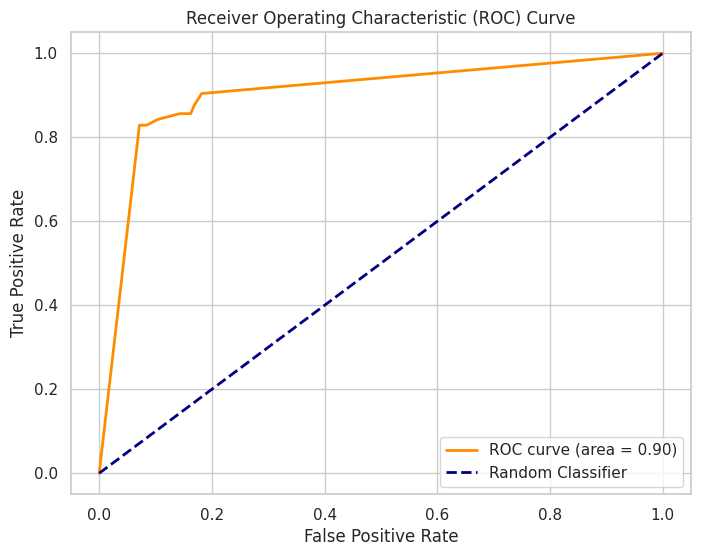

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for the test set
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Reasoning**:
I will define the hyperparameter grid for `DecisionTreeClassifier` as specified in the instructions, creating a dictionary `param_grid` with keys for `max_depth`, `min_samples_split`, and `min_samples_leaf`.



In [ ]:
param_grid = {
    'max_depth': [2, 4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 3, 4, 5]
}

print("Hyperparameter grid defined:")
print(param_grid)

Hyperparameter grid defined:
{'max_depth': [2, 4, 6, 8, 10], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 3, 4, 5]}


**Reasoning**:
The hyperparameter grid has been defined. Now, I need to perform GridSearchCV to find the best hyperparameters for the Decision Tree Classifier. This involves importing GridSearchCV, initializing it with the model and the parameter grid, and then fitting it to the training data.



In [ ]:
from sklearn.model_selection import GridSearchCV

# Initialize the DecisionTreeClassifier with the desired class_weight
dtc = DecisionTreeClassifier(random_state=42, class_weight={0:1, 1:1.5})

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")

Fitting 5 folds for each of 75 candidates, totalling 375 fits
GridSearchCV completed.


**Reasoning**:
After fitting GridSearchCV, the next step is to retrieve and display the best parameters found by the search. This will inform us which combination of hyperparameters yielded the best performance based on the chosen scoring metric.



In [ ]:
print("Best parameters found by GridSearchCV:")
print(grid_search.best_params_)

Best parameters found by GridSearchCV:
{'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [ ]:
best_dt_model = grid_search.best_estimator_
print("Best Decision Tree Model (from GridSearchCV):")
print(best_dt_model)

Best Decision Tree Model (from GridSearchCV):
DecisionTreeClassifier(class_weight={0: 1, 1: 1.5}, max_depth=8,
                       min_samples_leaf=4, min_samples_split=10,
                       random_state=42)


In [ ]:
y_pred = best_dt_model.predict(X_test)

print("Classification Report for Tuned Model:")
print(classification_report(y_test, y_pred))

Classification Report for Tuned Model:
              precision    recall  f1-score   support

           0       0.89      0.82      0.86       154
           1       0.83      0.90      0.86       146

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, recall_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}

results = []

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    results.append([name, acc, recall])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Recall_Class_1"])
results_df.sort_values(by="Recall_Class_1", ascending=False)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 583, number of negative: 617
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 735
[LightGBM] [Info] Number of data points in the train set: 1200, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.485833 -> initscore=-0.056682
[LightGBM] [Info] Start training from score -0.056682


,Model,Accuracy,Recall_Class_1
5,AdaBoost,1.000000,1.000000
4,Gradient Boosting,0.986667,0.986301
7,XGBoost,0.983333,0.972603
8,LightGBM,0.960000,0.952055
3,Random Forest,0.943333,0.952055
6,Naive Bayes,0.863333,0.883562
0,Logistic Regression,0.853333,0.856164
2,SVM,0.713333,0.636986
1,KNN,0.673333,0.630137


In [ ]:
from sklearn.metrics import classification_report

for name, clf in models.items():
    y_pred = clf.predict(X_test)
    print(f"\n--- Classification Report for {name} ---")
    print(classification_report(y_test, y_pred))


--- Classification Report for Logistic Regression ---
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       154
           1       0.84      0.86      0.85       146

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300


--- Classification Report for KNN ---
              precision    recall  f1-score   support

           0       0.67      0.71      0.69       154
           1       0.68      0.63      0.65       146

    accuracy                           0.67       300
   macro avg       0.67      0.67      0.67       300
weighted avg       0.67      0.67      0.67       300


--- Classification Report for SVM ---
              precision    recall  f1-score   support

           0       0.70      0.79      0.74       154
           1       0.74      0.64      0.68       146

    accuracy                           0.71      

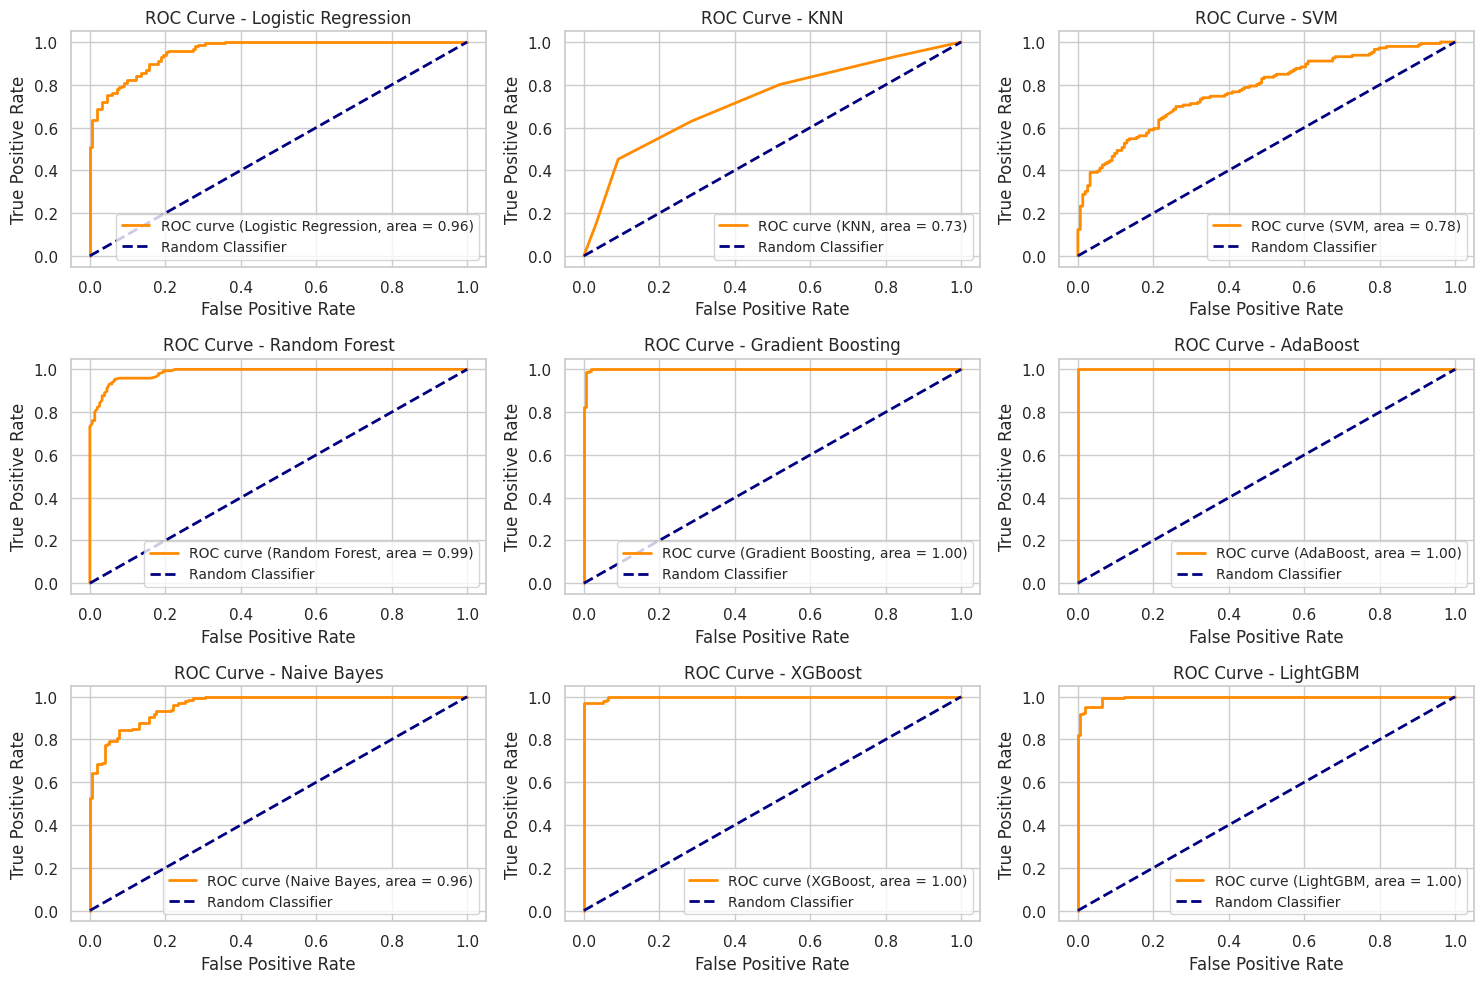

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

for i, (name, clf) in enumerate(models.items()):
    # Predict probabilities for the positive class
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed for 9 models
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve ({name}, area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(True)

plt.tight_layout()
plt.show()

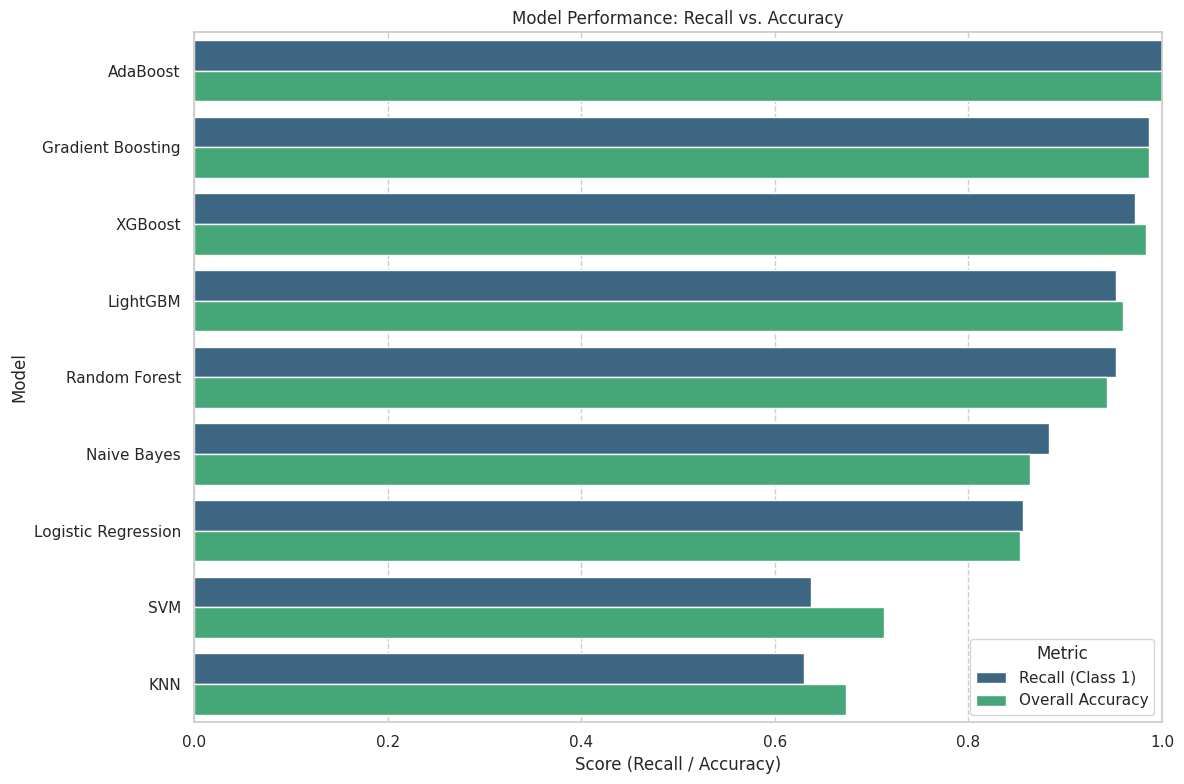

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure results_df is sorted by recall for consistent ordering
results_df_sorted = results_df.sort_values(by="Recall_Class_1", ascending=False)

# Melt the DataFrame to long format to plot both metrics on the same chart
# We'll include the 'Model' column for grouping, and 'Recall_Class_1' and 'Accuracy' as values
results_melted = results_df_sorted.melt(id_vars='Model', value_vars=['Recall_Class_1', 'Accuracy'],
                                       var_name='Metric', value_name='Value')

# Rename metrics for better plotting labels
results_melted['Metric'] = results_melted['Metric'].replace({'Recall_Class_1': 'Recall (Class 1)', 'Accuracy': 'Overall Accuracy'})

plt.figure(figsize=(12, 8))

sns.barplot(x='Value', y='Model', hue='Metric', data=results_melted, palette='viridis')
plt.title('Model Performance: Recall vs. Accuracy')
plt.xlabel('Score (Recall / Accuracy)')
plt.ylabel('Model')
plt.xlim(0, 1) # Scores are between 0 and 1
plt.legend(title='Metric')
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

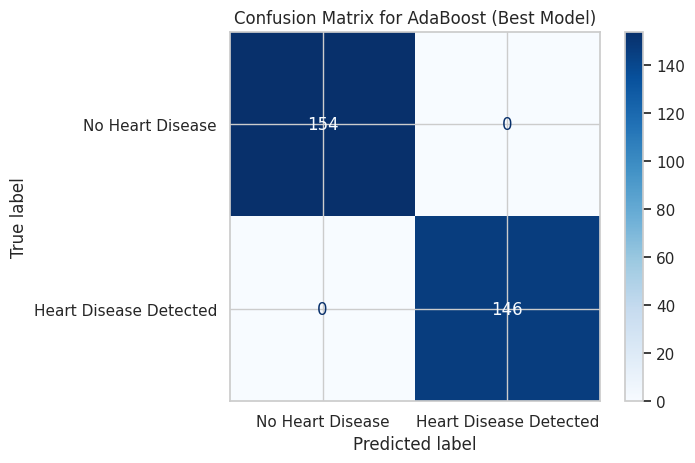

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Identify the best performing model
best_model_name = results_df_sorted.iloc[0]['Model']
best_model = models[best_model_name]

# Predict on the test data using the best model
y_pred_best_model = best_model.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_best_model)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Heart Disease', 'Heart Disease Detected'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for AdaBoost (Best Model)')
plt.show()

In [ ]:
import joblib

# Identify the best performing model (AdaBoost in this case, based on previous results)
best_model_name = results_df_sorted.iloc[0]['Model']
best_model = models[best_model_name]

# Save the best model
joblib.dump(best_model, 'best_ada_model.joblib')

print(f"Best performing model ({best_model_name}) saved as 'best_ada_model.joblib'")

Best performing model (AdaBoost) saved as 'best_ada_model.joblib'


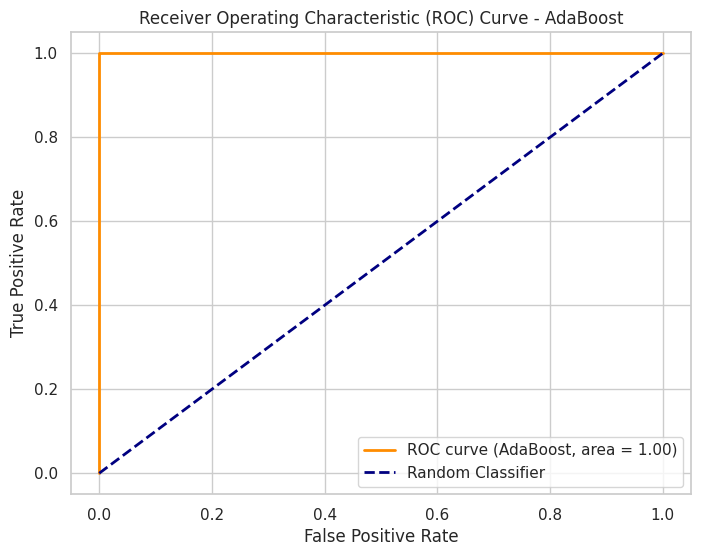

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get the AdaBoost model from the dictionary
adaboost_model = models['AdaBoost']

# Predict probabilities for the positive class
y_pred_proba_ada = adaboost_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr_ada, tpr_ada, thresholds_ada = roc_curve(y_test, y_pred_proba_ada)
roc_auc_ada = auc(fpr_ada, tpr_ada)

# Plot the ROC curve for AdaBoost
plt.figure(figsize=(8, 6))
plt.plot(fpr_ada, tpr_ada, color='darkorange', lw=2, label=f'ROC curve (AdaBoost, area = {roc_auc_ada:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - AdaBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
import joblib

model_path = "best_ada_model.joblib"
model = joblib.load(model_path)

print(type(model))


<class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'>


In [ ]:
import joblib

joblib.dump(important_features.tolist(), 'feature_names.joblib')

print("Important features saved to 'feature_names.joblib'")

Important features saved to 'feature_names.joblib'


## Load the Best Model and Identify Features


In [ ]:
import joblib

# Load the best performing model
loaded_model = joblib.load('best_ada_model.joblib')

# Load the feature names
loaded_feature_names = joblib.load('feature_names.joblib')

# Print the type of the loaded model
print(f"Type of loaded_model: {type(loaded_model)}")

# Print the loaded feature names
print(f"Loaded feature names: {loaded_feature_names}")

Type of loaded_model: <class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'>
Loaded feature names: ['Smoking', 'Age', 'Family Heart Disease', 'BMI', 'Cholesterol Level', 'Blood Pressure', 'Stress Level', 'Diabetes', 'Homocysteine Level']


## Define Preprocessing and Prediction Function




In [ ]:
import pandas as pd
import joblib

# Load the best performing model and feature names
loaded_model = joblib.load('best_ada_model.joblib')
loaded_feature_names = joblib.load('feature_names.joblib')
loaded_label_encoders = joblib.load('label_encoders.joblib') # Load the saved encoders

def predict_heart_disease(
    Smoking: str,
    Age: int,
    Family_Heart_Disease: str,
    BMI: float,
    Cholesterol_Level: int,
    Blood_Pressure: int,
    Stress_Level: str,
    Diabetes: str,
    Homocysteine_Level: float
) -> tuple:
    """
    Predicts heart disease status based on input features using a pre-trained model.

    Args:
        Smoking (str): 'Yes' or 'No'
        Age (int): Patient's age
        Family_Heart_Disease (str): 'Yes' or 'No'
        BMI (float): Body Mass Index
        Cholesterol_Level (int): Cholesterol level
        Blood_Pressure (int): Blood pressure
        Stress_Level (str): 'High', 'Low', or 'Medium'
        Diabetes (str): 'Yes' or 'No'
        Homocysteine_Level (float): Homocysteine level

    Returns:
        tuple: A tuple containing (pd.DataFrame of input features, str prediction result)
    """

    # Prepare a dictionary for the input values, matching the expected column names
    input_raw_data = {
        'Smoking': Smoking,
        'Age': Age,
        'Family Heart Disease': Family_Heart_Disease,
        'BMI': BMI,
        'Cholesterol Level': Cholesterol_Level,
        'Blood Pressure': Blood_Pressure,
        'Stress Level': Stress_Level,
        'Diabetes': Diabetes,
        'Homocysteine Level': Homocysteine_Level
    }

    # Create a DataFrame from the single row of input data
    input_df_processed = pd.DataFrame([input_raw_data])

    # Encode categorical features using the loaded encoders
    for col, encoder in loaded_label_encoders.items():
        if col in input_df_processed.columns:
            # Ensure the input value is known to the encoder, otherwise handle as unknown or raise error
            # For simplicity, we assume valid inputs based on training data categories
            input_df_processed[col] = encoder.transform(input_df_processed[col])

    # Select and order features according to the `loaded_feature_names`
    input_df = input_df_processed[loaded_feature_names]

    # Use the loaded_model to make a prediction
    prediction = loaded_model.predict(input_df)[0]

    # Convert the numerical prediction back into a user-friendly string
    if prediction == 1:
        result = 'Heart Disease Detected'
    else:
        result = 'No Heart Disease'

    # Return this user-friendly prediction string and the input DataFrame
    return input_df, result

print("The `predict_heart_disease` function has been defined and loaded resources.")

The `predict_heart_disease` function has been defined and loaded resources.


In [ ]:
print("Demonstrating the `predict_heart_disease` function with example inputs:")

# Example 1: No Heart Disease
input_df1, prediction1 = predict_heart_disease(
    Smoking='No',
    Age=45,
    Family_Heart_Disease='No',
    BMI=25.0,
    Cholesterol_Level=180,
    Blood_Pressure=120,
    Stress_Level='Low',
    Diabetes='No',
    Homocysteine_Level=10.0
)
print(f"Example 1 Input Features:\n{input_df1}")
print(f"Example 1 Prediction: {prediction1}")

# Example 2: Heart Disease Detected
input_df2, prediction2 = predict_heart_disease(
    Smoking='Yes',
    Age=65,
    Family_Heart_Disease='Yes',
    BMI=30.0,
    Cholesterol_Level=280,
    Blood_Pressure=160,
    Stress_Level='High',
    Diabetes='Yes',
    Homocysteine_Level=18.0
)
print(f"Example 2 Input Features:\n{input_df2}")
print(f"Example 2 Prediction: {prediction2}")

# Example 3: Mixed input to test edge cases
input_df3, prediction3 = predict_heart_disease(
    Smoking='No',
    Age=55,
    Family_Heart_Disease='Yes',
    BMI=28.5,
    Cholesterol_Level=220,
    Blood_Pressure=140,
    Stress_Level='Medium',
    Diabetes='No',
    Homocysteine_Level=14.5
)
print(f"Example 3 Input Features:\n{input_df3}")
print(f"Example 3 Prediction: {prediction3}")

Demonstrating the `predict_heart_disease` function with example inputs:
Example 1 Input Features:
   Smoking  Age  Family Heart Disease   BMI  Cholesterol Level  \
0        0   45                     0  25.0                180   

   Blood Pressure  Stress Level  Diabetes  Homocysteine Level  
0             120             1         0                10.0  
Example 1 Prediction: No Heart Disease
Example 2 Input Features:
   Smoking  Age  Family Heart Disease   BMI  Cholesterol Level  \
0        1   65                     1  30.0                280   

   Blood Pressure  Stress Level  Diabetes  Homocysteine Level  
0             160             0         1                18.0  
Example 2 Prediction: Heart Disease Detected
Example 3 Input Features:
   Smoking  Age  Family Heart Disease   BMI  Cholesterol Level  \
0        0   55                     1  28.5                220   

   Blood Pressure  Stress Level  Diabetes  Homocysteine Level  
0             140             2         0      

## Build USER Interface



In [ ]:
!pip install streamlit -qq
import streamlit as st
import pandas as pd
import joblib
from io import BytesIO

# -------------------- Page Config --------------------
st.set_page_config(
    page_title="Heart Disease Prediction App",
    layout="centered"
)

# -------------------- Load Model Artifacts --------------------
try:
    loaded_model = joblib.load("best_ada_model.joblib")
    loaded_feature_names = joblib.load("feature_names.joblib")
    loaded_label_encoders = joblib.load("label_encoders.joblib")
except FileNotFoundError as e:
    st.error(f"Error loading model artifacts: {e}")
    st.stop()

# -------------------- Prediction Function --------------------
def predict_heart_disease(
    Smoking: str,
    Age: int,
    Family_Heart_Disease: str,
    BMI: float,
    Cholesterol_Level: int,
    Blood_Pressure: int,
    Stress_Level: str,
    Diabetes: str,
    Homocysteine_Level: float
) -> str:

    input_raw_data = {
        "Smoking": Smoking,
        "Age": Age,
        "Family Heart Disease": Family_Heart_Disease,
        "BMI": BMI,
        "Cholesterol Level": Cholesterol_Level,
        "Blood Pressure": Blood_Pressure,
        "Stress Level": Stress_Level,
        "Diabetes": Diabetes,
        "Homocysteine Level": Homocysteine_Level
    }

    input_df = pd.DataFrame([input_raw_data])

    # Encode categorical features
    for col, encoder in loaded_label_encoders.items():
        if col in input_df.columns:
            try:
                input_df[col] = encoder.transform(input_df[col])
            except ValueError:
                return "Invalid input category detected"

    # Ensure correct feature order
    input_df = input_df[loaded_feature_names]

    prediction = loaded_model.predict(input_df)[0]

    return "High Risk of Heart Disease" if prediction == 1 else "Low Risk of Heart Disease"

# -------------------- Session State --------------------
if "records" not in st.session_state:
    st.session_state.records = []

if "last_result" not in st.session_state:
    st.session_state.last_result = None

if "reset_trigger" not in st.session_state:
    st.session_state.reset_trigger = False

# -------------------- Default Values --------------------
input_defaults = {
    "smoking": "No",
    "age": 45,
    "bmi": 25.0,
    "cholesterol_level": 200,
    "stress_level": "Low",
    "family_heart_disease": "No",
    "blood_pressure": 120,
    "diabetes": "No",
    "homocysteine_level": 10.0
}

# -------------------- UI --------------------
st.title("Heart Disease Prediction App")
st.write(
    "This application estimates heart disease risk using a trained machine learning model. "
    "Results are for educational purposes only and not a medical diagnosis."
)

st.header("Patient Information")

col1, col2 = st.columns(2)

# ---------- Column 1 ----------
with col1:
    smoking = st.selectbox("Smoking", ["No", "Yes"], key="smoking")
    age = st.number_input("Age", 1, 120, value=input_defaults["age"], key="age")

    bmi = st.number_input(
        "Body Mass Index (BMI)",
        10.0, 60.0,
        step=0.1,
        value=input_defaults["bmi"],
        key="bmi"
    )
    st.caption("BMI = weight (kg) / height² (m²)")

    cholesterol_level = st.number_input(
        "Cholesterol Level",
        100, 400,
        value=input_defaults["cholesterol_level"],
        key="cholesterol_level"
    )

    stress_level = st.selectbox(
        "Stress Level",
        ["Low", "Medium", "High"],
        key="stress_level"
    )

# ---------- Column 2 ----------
with col2:
    family_heart_disease = st.selectbox(
        "Family History of Heart Disease",
        ["No", "Yes"],
        key="family_heart_disease"
    )

    blood_pressure = st.number_input(
        "Blood Pressure",
        70, 250,
        value=input_defaults["blood_pressure"],
        key="blood_pressure"
    )

    diabetes = st.selectbox(
        "Diabetes",
        ["No", "Yes"],
        key="diabetes"
    )

    homocysteine_level = st.number_input(
        "Homocysteine Level",
        2.0, 50.0,
        step=0.1,
        value=input_defaults["homocysteine_level"],
        key="homocysteine_level"
    )

st.markdown("---")

# -------------------- Buttons --------------------
btn1, btn2 = st.columns(2)

with btn1:
    if st.button("Predict"):
        result = predict_heart_disease(
            Smoking=smoking,
            Age=age,
            Family_Heart_Disease=family_heart_disease,
            BMI=bmi,
            Cholesterol_Level=cholesterol_level,
            Blood_Pressure=blood_pressure,
            Stress_Level=stress_level,
            Diabetes=diabetes,
            Homocysteine_Level=homocysteine_level
        )

        st.session_state.last_result = result

        st.session_state.records.append({
            "Smoking": smoking,
            "Age": age,
            "Family Heart Disease": family_heart_disease,
            "BMI": bmi,
            "Cholesterol Level": cholesterol_level,
            "Blood Pressure": blood_pressure,
            "Stress Level": stress_level,
            "Diabetes": diabetes,
            "Homocysteine Level": homocysteine_level,
            "Prediction": result
        })

with btn2:
    if st.button("Reset"):
        st.session_state.clear()
        st.rerun()

# -------------------- Result Display (COLOR FIXED) --------------------
if st.session_state.last_result:
    st.subheader("Prediction Result")

    if st.session_state.last_result == "High Risk of Heart Disease":
        st.error(st.session_state.last_result)   # 🔴 RED
    else:
        st.success(st.session_state.last_result) # 🟢 GREEN

# -------------------- Records & Excel Export --------------------
if st.session_state.records:
    st.subheader("Patient Records")

    df = pd.DataFrame(st.session_state.records)
    st.dataframe(df, use_container_width=True)

    buffer = BytesIO()
    df.to_excel(buffer, index=False, engine="openpyxl")
    buffer.seek(0)

    st.download_button(
        label="Download Records (Excel)",
        data=buffer,
        file_name="patient_records.xlsx",
        mime="application/vnd.openxmlformats-officedocument.spreadsheetml.sheet"
    )


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 83.1 MB/s eta 0:00:00


2026-02-08 10:57:12.049 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-08 10:57:12.099 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-08 10:57:12.105 WARNING streamlit.runtime.state.session_state_proxy: Session state does not function when running a script without `streamlit run`
2026-02-08 10:57:12.109 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-08 10:57:12.114 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-08 10:57:12.123 WARNING streamlit.runtime.scriptrunner_utils.script_run_c

In [ ]:
from google.colab import files
streamlit_app_content = """
!pip install streamlit -qq
import streamlit as st
import pandas as pd
import joblib
from io import BytesIO

# -------------------- Page Config --------------------
st.set_page_config(
    page_title="Heart Disease Prediction App",
    layout="centered"
)

# -------------------- Load Model Artifacts --------------------
try:
    loaded_model = joblib.load("best_ada_model.joblib")
    loaded_feature_names = joblib.load("feature_names.joblib")
    loaded_label_encoders = joblib.load("label_encoders.joblib")
except FileNotFoundError as e:
    st.error(f"Error loading model artifacts: {e}")
    st.stop()

# -------------------- Prediction Function --------------------
def predict_heart_disease(
    Smoking: str,
    Age: int,
    Family_Heart_Disease: str,
    BMI: float,
    Cholesterol_Level: int,
    Blood_Pressure: int,
    Stress_Level: str,
    Diabetes: str,
    Homocysteine_Level: float
) -> str:

    input_raw_data = {
        "Smoking": Smoking,
        "Age": Age,
        "Family Heart Disease": Family_Heart_Disease,
        "BMI": BMI,
        "Cholesterol Level": Cholesterol_Level,
        "Blood Pressure": Blood_Pressure,
        "Stress Level": Stress_Level,
        "Diabetes": Diabetes,
        "Homocysteine Level": Homocysteine_Level
    }

    input_df = pd.DataFrame([input_raw_data])

    # Encode categorical features
    for col, encoder in loaded_label_encoders.items():
        if col in input_df.columns:
            try:
                input_df[col] = encoder.transform(input_df[col])
            except ValueError:
                return "Invalid input category detected"

    # Ensure correct feature order
    input_df = input_df[loaded_feature_names]

    prediction = loaded_model.predict(input_df)[0]

    return "High Risk of Heart Disease" if prediction == 1 else "Low Risk of Heart Disease"

# -------------------- Session State --------------------
if "records" not in st.session_state:
    st.session_state.records = []

if "last_result" not in st.session_state:
    st.session_state.last_result = None

if "reset_trigger" not in st.session_state:
    st.session_state.reset_trigger = False

# -------------------- Default Values --------------------
input_defaults = {
    "smoking": "No",
    "age": 45,
    "bmi": 25.0,
    "cholesterol_level": 200,
    "stress_level": "Low",
    "family_heart_disease": "No",
    "blood_pressure": 120,
    "diabetes": "No",
    "homocysteine_level": 10.0
}

# -------------------- UI --------------------
st.title("Heart Disease Prediction App")
st.write(
    "This application estimates heart disease risk using a trained machine learning model. "
    "Results are for educational purposes only and not a medical diagnosis."
)

st.header("Patient Information")

col1, col2 = st.columns(2)

# ---------- Column 1 ----------
with col1:
    smoking = st.selectbox("Smoking", ["No", "Yes"], key="smoking")
    age = st.number_input("Age", 1, 120, value=input_defaults["age"], key="age")

    bmi = st.number_input(
        "Body Mass Index (BMI)",
        10.0, 60.0,
        step=0.1,
        value=input_defaults["bmi"],
        key="bmi"
    )
    st.caption("BMI = weight (kg) / height² (m²)")

    cholesterol_level = st.number_input(
        "Cholesterol Level",
        100, 400,
        value=input_defaults["cholesterol_level"],
        key="cholesterol_level"
    )

    stress_level = st.selectbox(
        "Stress Level",
        ["Low", "Medium", "High"],
        key="stress_level"
    )

# ---------- Column 2 ----------
with col2:
    family_heart_disease = st.selectbox(
        "Family History of Heart Disease",
        ["No", "Yes"],
        key="family_heart_disease"
    )

    blood_pressure = st.number_input(
        "Blood Pressure",
        70, 250,
        value=input_defaults["blood_pressure"],
        key="blood_pressure"
    )

    diabetes = st.selectbox(
        "Diabetes",
        ["No", "Yes"],
        key="diabetes"
    )

    homocysteine_level = st.number_input(
        "Homocysteine Level",
        2.0, 50.0,
        step=0.1,
        value=input_defaults["homocysteine_level"],
        key="homocysteine_level"
    )

st.markdown("---")

# -------------------- Buttons --------------------
btn1, btn2 = st.columns(2)

with btn1:
    if st.button("Predict"):
        result = predict_heart_disease(
            Smoking=smoking,
            Age=age,
            Family_Heart_Disease=family_heart_disease,
            BMI=bmi,
            Cholesterol_Level=cholesterol_level,
            Blood_Pressure=blood_pressure,
            Stress_Level=stress_level,
            Diabetes=diabetes,
            Homocysteine_Level=homocysteine_level
        )

        st.session_state.last_result = result

        st.session_state.records.append({
            "Smoking": smoking,
            "Age": age,
            "Family Heart Disease": family_heart_disease,
            "BMI": bmi,
            "Cholesterol Level": cholesterol_level,
            "Blood Pressure": blood_pressure,
            "Stress Level": stress_level,
            "Diabetes": diabetes,
            "Homocysteine Level": homocysteine_level,
            "Prediction": result
        })

with btn2:
    if st.button("Reset"):
        st.session_state.clear()
        st.rerun()

# -------------------- Result Display (COLOR FIXED) --------------------
if st.session_state.last_result:
    st.subheader("Prediction Result")

    if st.session_state.last_result == "High Risk of Heart Disease":
        st.error(st.session_state.last_result)   # RED
    else:
        st.success(st.session_state.last_result) # GREEN

# -------------------- Records & Excel Export --------------------
if st.session_state.records:
    st.subheader("Patient Records")

    df = pd.DataFrame(st.session_state.records)
    st.dataframe(df, use_container_width=True)

    buffer = BytesIO()
    df.to_excel(buffer, index=False, engine="openpyxl")
    buffer.seek(0)

    st.download_button(
        label="Download Records (Excel)",
        data=buffer,
        file_name="patient_records.xlsx",
        mime="application/vnd.openxmlformats-officedocument.spreadsheetml.sheet"
    )
"""

# Write the content to app_streamlit.py
with open('app_streamlit.py', 'w') as f:
    f.write(streamlit_app_content)

# Now download the file
files.download('app_streamlit.py')

print("Downloaded 'app_streamlit.py' file.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded 'app_streamlit.py' file.


In [ ]:
df_encoded.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,Stress Level,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,69,1,110,269,2,1,1,0,23.9,1,8.9,293,116,6.23,15.75,1
1,76,1,91,223,2,0,0,0,28.4,0,7.8,134,72,8.36,11.83,0
2,48,0,117,187,0,0,1,1,33.9,1,8.2,124,111,1.62,12.52,0
3,50,0,137,304,2,0,0,1,28.1,1,6.6,82,136,8.66,18.38,0
4,61,0,91,276,0,0,0,1,18.9,2,6.6,296,147,9.46,15.51,0


In [ ]:
from google.colab import files

# Save the encoded dataset to a new CSV file
df_encoded.to_csv('df_encoded.csv', index=False)
print("Encoded dataset saved as 'df_encoded.csv'")

# Download the file
files.download('df_encoded.csv')

Encoded dataset saved as 'df_encoded.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>